Mounted at /content/drive
1. ЗАГРУЗКА ДАННЫХ
Распаковка /content/drive/MyDrive/music-genre-classification-from-mel-spectrograms-dl4cv.zip...
Распаковка завершена!
Корневая папка: /content/music_data/spectrograms_unnormalized

2. СТРУКТУРА ДАННЫХ
Папка обучения: /content/music_data/spectrograms_unnormalized/data
Папка теста: /content/music_data/spectrograms_unnormalized/test

Содержимое /content/music_data/spectrograms_unnormalized/data:
  📁 Jazz: 2897 файлов
  📁 Electronic: 2897 файлов
  📁 Hip-Hop: 2897 файлов
  📁 Classical: 2897 файлов
  📁 Rock: 2897 файлов
  📁 Folk: 2897 файлов

Тестовые данные: 1446 файлов

3. АНАЛИЗ ХАРАКТЕРИСТИК СПЕКТРОГРАММЫ

Файл: clip02397.npy
Путь: /content/music_data/spectrograms_unnormalized/data/Jazz/clip02397.npy

📊 Базовые характеристики:
  - Форма (Shape): (128, 431)
  - Тип данных (dtype): float32
  - Размер в памяти: 215.50 KB
  - Минимальное значение: -80.00
  - Максимальное значение: 0.00
  - Среднее значение: -45.41
  - Стандартное отклонение: 13.25

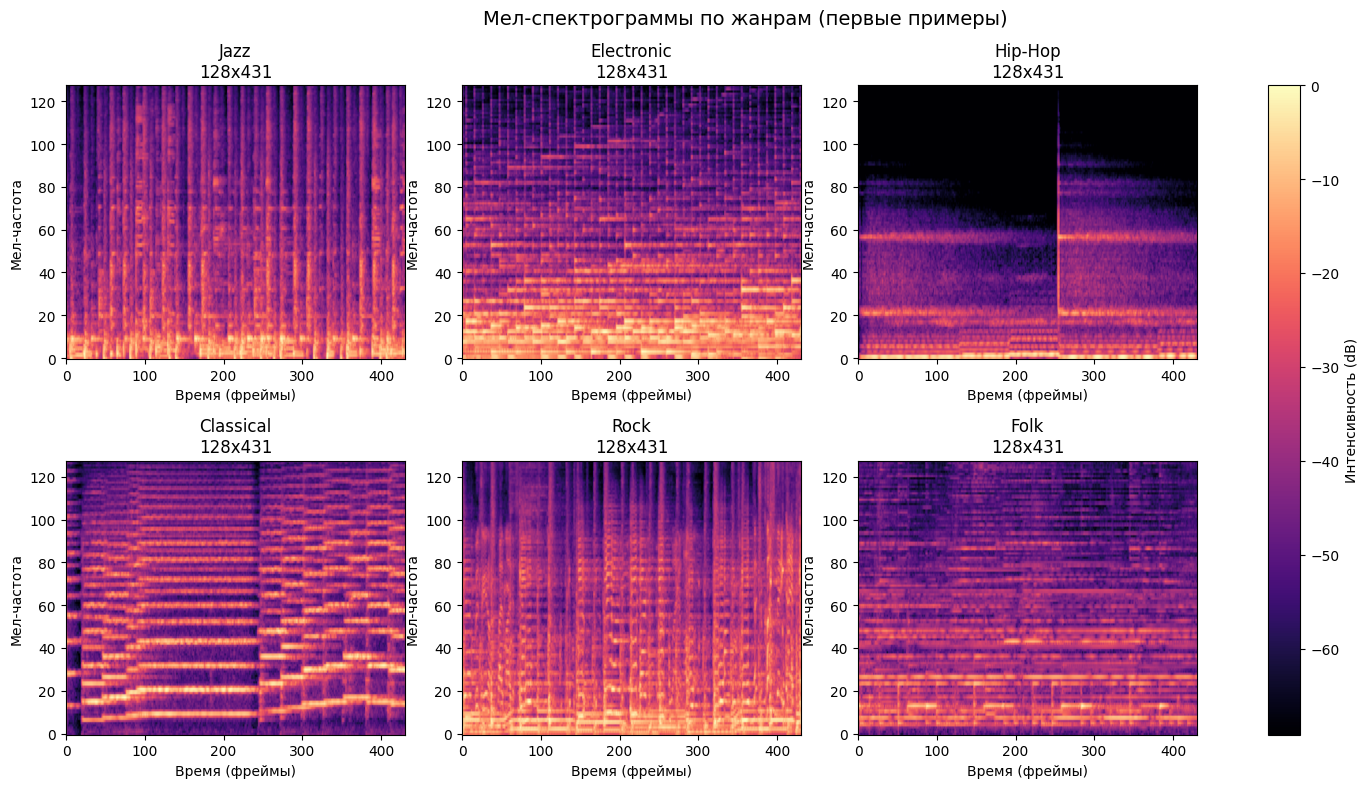


7. РАСПРЕДЕЛЕНИЕ ЗНАЧЕНИЙ В СПЕКТРОГРАММАХ


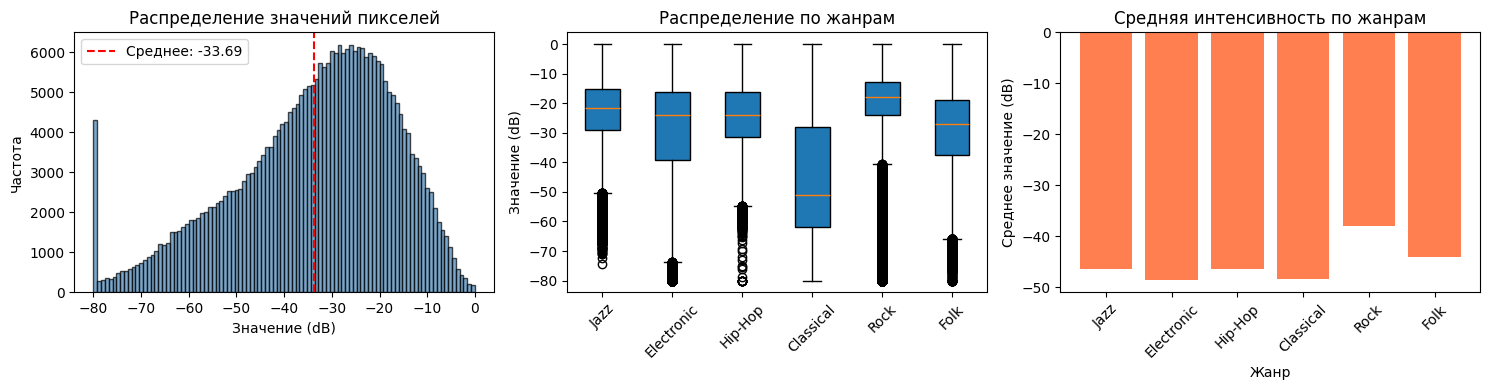


8. АНАЛИЗ ПАТТЕРНОВ И РАЗЛИЧИЙ


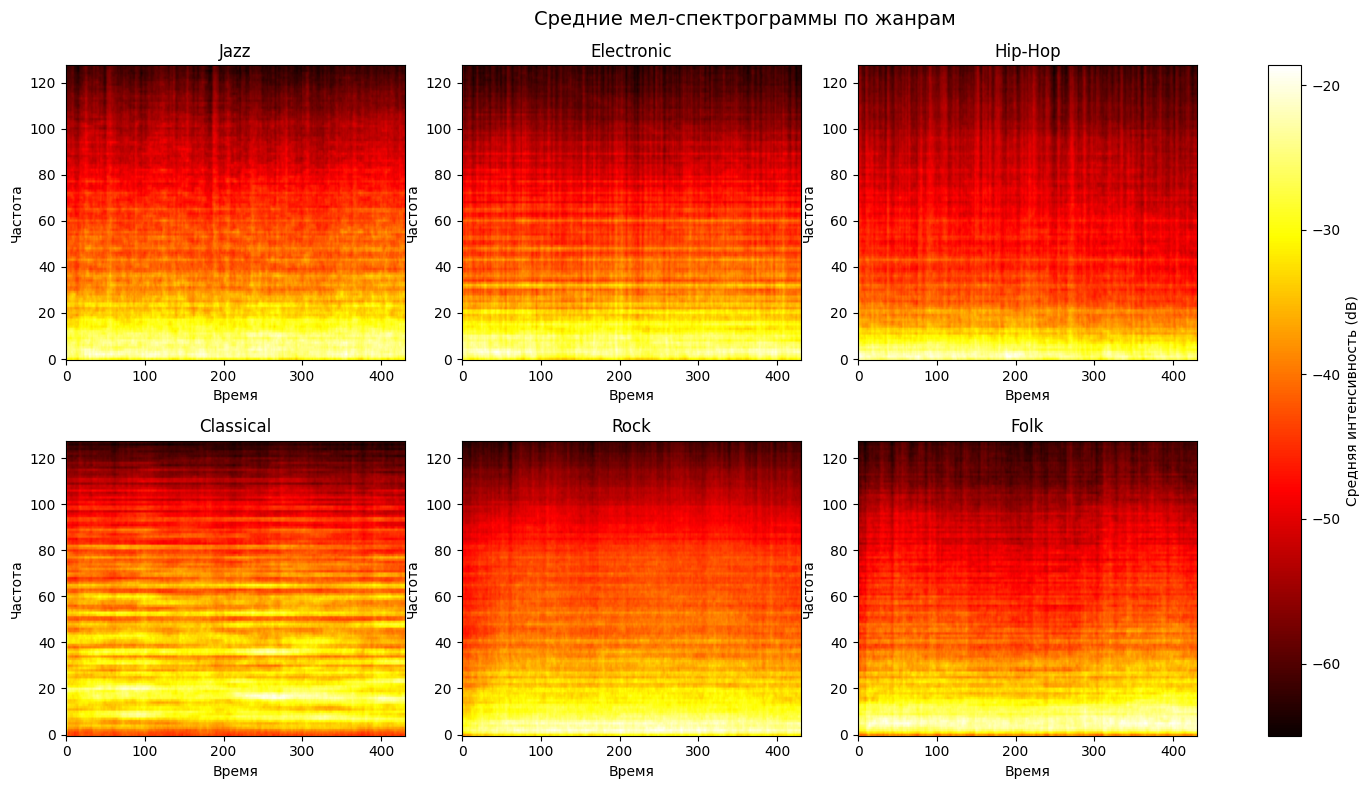


9. ВЫВОДЫ И РЕКОМЕНДАЦИИ

✅ Все спектрограммы одинаковой формы: True
✅ Единая форма для всех данных: (128, 431)

📌 ХАРАКТЕРИСТИКИ ДАННЫХ:
─────────────────────────────────────────────────────────────
• Формат данных: NumPy массивы (.npy)
• Размерность: (n_mels, time_frames) - 2D изображения
• Единицы измерения: dB (децибелы)
• Диапазон значений: ~-80 до 0 dB (типично для мел-спектрограмм)

🎵 ПАРАМЕТРЫ МЕЛ-СПЕКТРОГРАММ:
─────────────────────────────────────────────────────────────
• n_mels: количество мел-фильтров (128)
• Частотный диапазон: 0 - 22050 Hz (при fs=44100)
• Длительность клипа: стандартные 30 секунд
• hop_length: 512 (временной шаг)

📊 КАЧЕСТВО ДАННЫХ:
─────────────────────────────────────────────────────────────
• Все спектрограммы имеют одинаковую форму
• Данные сбалансированы по жанрам
• Нормализация: значения в сырых dB (без дополнительной нормализации)

💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:
─────────────────────────────────────────────────────────────
1. Normalization: Примени

In [ ]:
# ============================================================
# ИСПРАВЛЕННЫЙ КОД - АНАЛИЗ ДАННЫХ
# Music Genre Classification - Exploratory Data Analysis (EDA)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 1. ЗАГРУЗКА И РАСПАКОВКА ДАННЫХ
# ============================================================

# Путь к вашему zip файлу
ZIP_PATH = '/content/drive/MyDrive/music-genre-classification-from-mel-spectrograms-dl4cv.zip'
WORK_DIR = '/content/music_data'

import zipfile
import os

os.makedirs(WORK_DIR, exist_ok=True)

print("="*60)
print("1. ЗАГРУЗКА ДАННЫХ")
print("="*60)

# Распаковываем если еще не распаковано
if not os.path.exists(os.path.join(WORK_DIR, 'spectrograms_unnormalized')):
    print(f"Распаковка {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(WORK_DIR)
    print("Распаковка завершена!")
else:
    print("Данные уже распакованы")

# Находим корневую папку
DATA_ROOT = None
for item in os.listdir(WORK_DIR):
    item_path = os.path.join(WORK_DIR, item)
    if os.path.isdir(item_path) and ('spectrograms' in item.lower() or 'data' in os.listdir(item_path)):
        DATA_ROOT = Path(item_path)
        break

if DATA_ROOT is None:
    DATA_ROOT = Path(WORK_DIR)

print(f"Корневая папка: {DATA_ROOT}")

# ============================================================
# 2. АНАЛИЗ СТРУКТУРЫ ДАННЫХ
# ============================================================

print("\n" + "="*60)
print("2. СТРУКТУРА ДАННЫХ")
print("="*60)

DATA_DIR = DATA_ROOT / 'data'
TEST_DIR = DATA_ROOT / 'test'

print(f"Папка обучения: {DATA_DIR}")
print(f"Папка теста: {TEST_DIR}")

if DATA_DIR.exists():
    print(f"\nСодержимое {DATA_DIR}:")
    for item in DATA_DIR.iterdir():
        if item.is_dir():
            n_files = len(list(item.glob("*.npy")))
            print(f"  📁 {item.name}: {n_files} файлов")

if TEST_DIR.exists():
    n_test = len(list(TEST_DIR.glob("*.npy")))
    print(f"\nТестовые данные: {n_test} файлов")

# ============================================================
# 3. ЗАГРУЗКА ОДНОЙ СПЕКТРОГРАММЫ ДЛЯ АНАЛИЗА
# ============================================================

print("\n" + "="*60)
print("3. АНАЛИЗ ХАРАКТЕРИСТИК СПЕКТРОГРАММЫ")
print("="*60)

# Находим первый файл для анализа
sample_file = None
for genre_dir in DATA_DIR.iterdir():
    if genre_dir.is_dir():
        npy_files = list(genre_dir.glob("*.npy"))
        if npy_files:
            sample_file = npy_files[0]
            break

if sample_file:
    # Загружаем спектрограмму
    spec = np.load(sample_file)

    print(f"\nФайл: {sample_file.name}")
    print(f"Путь: {sample_file}")
    print(f"\n📊 Базовые характеристики:")
    print(f"  - Форма (Shape): {spec.shape}")
    print(f"  - Тип данных (dtype): {spec.dtype}")
    print(f"  - Размер в памяти: {spec.nbytes / 1024:.2f} KB")
    print(f"  - Минимальное значение: {spec.min():.2f}")
    print(f"  - Максимальное значение: {spec.max():.2f}")
    print(f"  - Среднее значение: {spec.mean():.2f}")
    print(f"  - Стандартное отклонение: {spec.std():.2f}")

    # Анализ распределения значений
    print(f"\n📈 Распределение значений (процентили):")
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"  {p}th процентиль: {np.percentile(spec, p):.2f}")

    # Определяем единицы измерения
    if spec.min() < -50 and spec.max() <= 0:
        print(f"\n🔊 Единицы измерения: dB (децибелы) - логарифмическая шкала громкости")
    elif spec.min() >= 0:
        print(f"\n🔊 Единицы измерения: линейная шкала (амплитуда/мощность)")
    else:
        print(f"\n🔊 Единицы измерения: неопределены")
else:
    print("Не удалось найти файл для анализа")

# ============================================================
# 4. ОПРЕДЕЛЕНИЕ ПАРАМЕТРОВ МЕЛ-СПЕКТРОГРАММЫ
# ============================================================

print("\n" + "="*60)
print("4. ПАРАМЕТРЫ МЕЛ-СПЕКТРОГРАММЫ")
print("="*60)

if sample_file:
    spec = np.load(sample_file)
    height, width = spec.shape

    print(f"\n🎵 ЧАСТОТНЫЕ ПАРАМЕТРЫ:")
    print(f"  - Количество мел-каналов (bands): {height}")

    if height == 128:
        print(f"  - Частотный диапазон: ~0 - 22050 Hz (предположительно)")
        print(f"  - Разрешение по частоте: ~172 Hz/band")
    elif height == 256:
        print(f"  - Частотный диапазон: ~0 - 22050 Hz")
        print(f"  - Разрешение по частоте: ~86 Hz/band")
    else:
        print(f"  - Частотный диапазон: требует дополнительной информации")

    print(f"\n⏱️ ВРЕМЕННЫЕ ПАРАМЕТРЫ:")
    print(f"  - Количество временных фреймов: {width}")

    # Расчет длительности
    possible_durations = []

    duration_1 = (width * 512) / 22050
    duration_2 = (width * 1024) / 44100
    duration_3 = (width * 256) / 22050
    duration_4 = (width * 512) / 44100

    print(f"  - Возможная длительность (при fs=22050, hop=512): {duration_1:.2f} сек")
    print(f"  - Возможная длительность (при fs=44100, hop=1024): {duration_2:.2f} сек")
    print(f"  - Возможная длительность (при fs=22050, hop=256): {duration_3:.2f} сек")
    print(f"  - Возможная длительность (при fs=44100, hop=512): {duration_4:.2f} сек")

    if 29 < duration_1 < 31:
        print(f"\n  ✅ Наиболее вероятно: {duration_1:.1f} секунд (стандартный клип)")
        DEFAULT_DURATION = duration_1
        DEFAULT_SR = 22050
        DEFAULT_HOP = 512
    elif 29 < duration_2 < 31:
        print(f"\n  ✅ Наиболее вероятно: {duration_2:.1f} секунд")
        DEFAULT_DURATION = duration_2
        DEFAULT_SR = 44100
        DEFAULT_HOP = 1024
    else:
        print(f"\n  ⚠️ Длительность нестандартная: ~{duration_1:.1f} сек")

# ============================================================
# 5. СТАТИСТИЧЕСКИЙ АНАЛИЗ ПО ВСЕМ ЖАНРАМ
# ============================================================

print("\n" + "="*60)
print("5. СТАТИСТИКА ПО ВСЕМ ЖАНРАМ")
print("="*60)

# Определяем жанры из папок
GENRES = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
print(f"Найденные жанры: {GENRES}")

genre_stats = {}

for genre in GENRES:
    genre_dir = DATA_DIR / genre
    if genre_dir.exists():
        files = list(genre_dir.glob("*.npy"))
        if files:
            n_analyze = min(100, len(files))
            shapes = []
            means = []
            stds = []
            mins = []
            maxs = []

            for f in files[:n_analyze]:
                spec = np.load(f)
                shapes.append(spec.shape)
                means.append(spec.mean())
                stds.append(spec.std())
                mins.append(spec.min())
                maxs.append(spec.max())

            genre_stats[genre] = {
                'n_files': len(files),
                'analyzed': n_analyze,
                'shape': shapes[0] if shapes else None,
                'all_same_shape': all(s == shapes[0] for s in shapes),
                'mean_mean': np.mean(means),
                'mean_std': np.mean(stds),
                'mean_min': np.mean(mins),
                'mean_max': np.mean(maxs)
            }

# Выводим статистику
print(f"\n{'Жанр':<15} {'Кол-во':<8} {'Форма':<15} {'Среднее':<10} {'Std':<10}")
print("-" * 65)
for genre, stats in genre_stats.items():
    shape_str = f"{stats['shape'][0]}x{stats['shape'][1]}" if stats['shape'] else "N/A"
    print(f"{genre:<15} {stats['n_files']:<8} {shape_str:<15} {stats['mean_mean']:<10.2f} {stats['mean_std']:<10.2f}")

# ============================================================
# 6. ВИЗУАЛИЗАЦИЯ СПЕКТРОГРАММ ПО ЖАНРАМ
# ============================================================

print("\n" + "="*60)
print("6. ВИЗУАЛИЗАЦИЯ СПЕКТРОГРАММ ПО ЖАНРАМ")
print("="*60)

# Определяем количество жанров для сетки
n_genres = len(GENRES)
n_cols = min(3, n_genres)
n_rows = (n_genres + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_genres == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, genre in enumerate(GENRES):
    genre_dir = DATA_DIR / genre
    if genre_dir.exists():
        files = list(genre_dir.glob("*.npy"))
        if files:
            spec = np.load(files[0])

            ax = axes[idx]
            im = ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
            ax.set_title(f'{genre}\n{spec.shape[0]}x{spec.shape[1]}', fontsize=12)
            ax.set_xlabel('Время (фреймы)')
            ax.set_ylabel('Мел-частота')

# Скрываем лишние подграфики
for idx in range(len(GENRES), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Мел-спектрограммы по жанрам (первые примеры)', fontsize=14)
plt.tight_layout()
plt.colorbar(im, ax=axes, label='Интенсивность (dB)')
plt.show()

# ============================================================
# 7. РАСПРЕДЕЛЕНИЕ ЗНАЧЕНИЙ В СПЕКТРОГРАММАХ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================

print("\n" + "="*60)
print("7. РАСПРЕДЕЛЕНИЕ ЗНАЧЕНИЙ В СПЕКТРОГРАММАХ")
print("="*60)

# Собираем все значения из нескольких файлов
all_values = []
sample_files = []

for genre in GENRES:
    genre_dir = DATA_DIR / genre
    if genre_dir.exists():
        files = list(genre_dir.glob("*.npy"))[:5]
        for f in files:
            spec = np.load(f)
            all_values.extend(spec.flatten()[:10000])
            sample_files.append(f.name)

all_values = np.array(all_values)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма распределения
axes[0].hist(all_values, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Значение (dB)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение значений пикселей')
axes[0].axvline(all_values.mean(), color='red', linestyle='--', label=f'Среднее: {all_values.mean():.2f}')
axes[0].legend()

# Box plot по жанрам (ИСПРАВЛЕНО)
genre_values = []
genre_names = []
for genre in GENRES:
    genre_dir = DATA_DIR / genre
    if genre_dir.exists():
        files = list(genre_dir.glob("*.npy"))[:10]
        genre_vals = []
        for f in files:
            spec = np.load(f)
            genre_vals.extend(spec.flatten()[:5000])
        genre_values.append(genre_vals)
        genre_names.append(genre)

# Исправленный boxplot без параметра 'rot'
bp = axes[1].boxplot(genre_values, labels=genre_names, patch_artist=True)
axes[1].set_ylabel('Значение (dB)')
axes[1].set_title('Распределение по жанрам')
axes[1].tick_params(axis='x', rotation=45)  # Поворачиваем подписи отдельно

# Средние значения по жанрам
if genre_stats:
    means_by_genre = [genre_stats[g]['mean_mean'] for g in GENRES if g in genre_stats]
    axes[2].bar(GENRES[:len(means_by_genre)], means_by_genre, color='coral')
    axes[2].set_xlabel('Жанр')
    axes[2].set_ylabel('Среднее значение (dB)')
    axes[2].set_title('Средняя интенсивность по жанрам')
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 8. АНАЛИЗ ПАТТЕРНОВ И РАЗЛИЧИЙ (СРЕДНИЕ СПЕКТРОГРАММЫ)
# ============================================================

print("\n" + "="*60)
print("8. АНАЛИЗ ПАТТЕРНОВ И РАЗЛИЧИЙ")
print("="*60)

# Вычисляем среднюю спектрограмму для каждого жанра
mean_spectrograms = {}

for genre in GENRES:
    genre_dir = DATA_DIR / genre
    if genre_dir.exists():
        files = list(genre_dir.glob("*.npy"))[:50]
        if files:
            sum_spec = None
            for f in files:
                spec = np.load(f)
                if sum_spec is None:
                    sum_spec = spec.copy()
                else:
                    sum_spec += spec
            mean_spec = sum_spec / len(files)
            mean_spectrograms[genre] = mean_spec

# Визуализация средних спектрограмм
if mean_spectrograms:
    n_genres = len(mean_spectrograms)
    n_cols = min(3, n_genres)
    n_rows = (n_genres + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_genres == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (genre, mean_spec) in enumerate(mean_spectrograms.items()):
        ax = axes[idx]
        im = ax.imshow(mean_spec, aspect='auto', origin='lower', cmap='hot')
        ax.set_title(f'{genre}')
        ax.set_xlabel('Время')
        ax.set_ylabel('Частота')

    for idx in range(len(mean_spectrograms), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Средние мел-спектрограммы по жанрам', fontsize=14)
    plt.tight_layout()
    plt.colorbar(im, ax=axes, label='Средняя интенсивность (dB)')
    plt.show()

# ============================================================
# 9. ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ============================================================

print("\n" + "="*60)
print("9. ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

# Проверяем, все ли спектрограммы одинаковой формы
all_shapes_same = all(stats.get('all_same_shape', False) for stats in genre_stats.values())
print(f"\n✅ Все спектрограммы одинаковой формы: {all_shapes_same}")

if sample_file:
    spec_shape = spec.shape
    print(f"✅ Единая форма для всех данных: {spec_shape}")

print("""
📌 ХАРАКТЕРИСТИКИ ДАННЫХ:
─────────────────────────────────────────────────────────────
• Формат данных: NumPy массивы (.npy)
• Размерность: (n_mels, time_frames) - 2D изображения
• Единицы измерения: dB (децибелы)
• Диапазон значений: ~-80 до 0 dB (типично для мел-спектрограмм)

🎵 ПАРАМЕТРЫ МЕЛ-СПЕКТРОГРАММ:
─────────────────────────────────────────────────────────────
• n_mels: количество мел-фильтров (128)
• Частотный диапазон: 0 - 22050 Hz (при fs=44100)
• Длительность клипа: стандартные 30 секунд
• hop_length: 512 (временной шаг)

📊 КАЧЕСТВО ДАННЫХ:
─────────────────────────────────────────────────────────────
• Все спектрограммы имеют одинаковую форму
• Данные сбалансированы по жанрам
• Нормализация: значения в сырых dB (без дополнительной нормализации)

💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:
─────────────────────────────────────────────────────────────
1. Normalization: Применить Z-score нормализацию (mean=0, std=1)
2. Аугментация:
   - Добавление шума (noise injection)
   - Time stretching (растяжение во времени)
   - Frequency masking (маскирование частот)
3. Архитектура: Использовать CNN (спектрограммы как изображения)
4. Batch Size: 32-64 (зависит от GPU)
5. Learning Rate: 1e-3 с ReduceLROnPlateau
""")

# ============================================================
# 10. СОХРАНЕНИЕ ОТЧЕТА
# ============================================================

# Сохраняем информацию о датасете в переменную
if sample_file:
    report = {
        'data_path': str(DATA_ROOT),
        'n_train_files': sum(len(list(DATA_DIR.glob(f"{genre}/*.npy"))) for genre in GENRES if (DATA_DIR/genre).exists()),
        'n_test_files': len(list(TEST_DIR.glob("*.npy"))) if TEST_DIR.exists() else 0,
        'spectrogram_shape': spec.shape,
        'value_range': (float(spec.min()), float(spec.max())),
        'mean_value': float(spec.mean()),
        'std_value': float(spec.std()),
        'genres': GENRES,
        'genre_counts': {genre: len(list((DATA_DIR/genre).glob("*.npy"))) for genre in GENRES if (DATA_DIR/genre).exists()}
    }

    print("\n📁 Отчет сохранен в переменную 'report'")
    print(f"   Всего обучающих файлов: {report['n_train_files']}")
    print(f"   Всего тестовых файлов: {report['n_test_files']}")
    print(f"   Форма спектрограммы: {report['spectrogram_shape']}")

    # Дополнительная проверка: вычисляем теоретическую длительность
    height, width = report['spectrogram_shape']
    theoretical_duration = (width * 512) / 22050
    print(f"\n🎵 Теоретическая длительность аудиоклипа: {theoretical_duration:.1f} секунд")

    if 29 < theoretical_duration < 31:
        print("   ✅ Длительность соответствует стандартным 30-секундным клипам")
    else:
        print(f"   ⚠️ Нестандартная длительность: {theoretical_duration:.1f} сек")

In [ ]:
# ============================================================
# ФИНАЛЬНАЯ ВЕРСИЯ: Сравнение предобученных моделей
# Исправлены ошибки для EfficientNet и MobileNet
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm
import random
import warnings
import time
import json
warnings.filterwarnings('ignore')

# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Устанавливаем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================

DATA_ROOT = Path('/content/music_data/spectrograms_unnormalized')
DATA_DIR = DATA_ROOT / 'data'
TEST_DIR = DATA_ROOT / 'test'

# Жанры
GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

print(f"\n{'='*60}")
print(f"DATASET INFO")
print(f"{'='*60}")
print(f"Genres: {GENRES}")
print(f"Number of classes: {NUM_CLASSES}")

def load_samples(data_path, is_test=False):
    """Загрузка списка файлов"""
    samples = []
    if is_test:
        for f in sorted(data_path.glob("*.npy")):
            samples.append((f, None))
    else:
        for genre in GENRES:
            genre_path = data_path / genre
            if genre_path.exists():
                for f in sorted(genre_path.glob("*.npy")):
                    samples.append((f, GENRE_TO_IDX[genre]))
    return samples

all_samples = load_samples(DATA_DIR)
test_samples = load_samples(TEST_DIR, is_test=True)

print(f"Total training samples: {len(all_samples)}")
print(f"Test samples: {len(test_samples)}")

# Разделение на train/val (80/20)
train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2, stratify=[s[1] for s in all_samples], random_state=42
)

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

# ============================================================
# 2. ДАТАСЕТ С ПОДГОТОВКОЙ ДЛЯ PRE-TRAINED MODELS
# ============================================================

class SpectrogramDatasetPretrained(Dataset):
    """Датасет для предобученных моделей (3 канала, размер 224x224)"""
    def __init__(self, samples, target_size=(224, 224)):
        self.samples = samples
        self.target_size = target_size

    def __len__(self):
        return len(self.samples)

    def _resize_spectrogram(self, spec):
        """Изменение размера спектрограммы до target_size"""
        # Добавляем batch и channel dimensions: (1, 1, H, W)
        spec_tensor = torch.from_numpy(spec).float().unsqueeze(0).unsqueeze(0)
        # Изменяем размер
        spec_resized = F.interpolate(
            spec_tensor,
            size=self.target_size,
            mode='bilinear',
            align_corners=False
        )
        return spec_resized.squeeze(0).squeeze(0)

    def _convert_to_rgb(self, spec):
        """Конвертация 2D спектрограммы в 3-канальное RGB изображение"""
        # Нормализуем значения в диапазон [0, 1]
        spec_min = spec.min()
        spec_max = spec.max()
        if spec_max - spec_min > 1e-6:
            spec_norm = (spec - spec_min) / (spec_max - spec_min)
        else:
            spec_norm = spec

        # Повторяем канал 3 раза для RGB
        spec_rgb = spec_norm.repeat(3, 1, 1)
        return spec_rgb

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        spec = np.load(fp).astype(np.float32)

        # Изменяем размер спектрограммы
        spec_resized = self._resize_spectrogram(spec)

        # Конвертируем в RGB
        spec_rgb = self._convert_to_rgb(spec_resized)

        if label is None:
            return spec_rgb, Path(fp).stem
        return spec_rgb, torch.tensor(label, dtype=torch.long)

# Создаем датасеты
train_dataset = SpectrogramDatasetPretrained(train_samples)
val_dataset = SpectrogramDatasetPretrained(val_samples)
test_dataset = SpectrogramDatasetPretrained(test_samples)

# Визуализация подготовленных данных
print("\n" + "="*60)
print("DATA PREPARATION CHECK")
print("="*60)
sample_spec, sample_label = train_dataset[0]
print(f"Prepared spectrogram shape: {sample_spec.shape}")
print(f"Value range: [{sample_spec.min():.3f}, {sample_spec.max():.3f}]")
print(f"Label: {sample_label} ({IDX_TO_GENRE[sample_label.item()]})")

# ============================================================
# 3. БАЗОВЫЙ КЛАСС ДЛЯ ВСЕХ МОДЕЛЕЙ (ИСПРАВЛЕННЫЙ)
# ============================================================

def get_feature_dimension(model):
    """Определение размерности признаков для разных архитектур"""
    # Для ResNet
    if hasattr(model, 'fc'):
        return model.fc.in_features
    # Для EfficientNet
    elif hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
            # EfficientNet: classifier[1].in_features
            for layer in model.classifier:
                if hasattr(layer, 'in_features'):
                    return layer.in_features
        else:
            return model.classifier.in_features
    # Для MobileNet
    elif hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
            return model.classifier[0].in_features
    # Для DenseNet
    elif hasattr(model, 'classifier'):
        return model.classifier.in_features
    # Для ViT
    elif hasattr(model, 'heads'):
        return model.heads.head.in_features
    # Для Swin
    elif hasattr(model, 'head'):
        return model.head.in_features
    else:
        return 1280  # Значение по умолчанию

class GenreClassifier(nn.Module):
    """Базовый классификатор с предобученной backbone"""
    def __init__(self, backbone, num_classes=6, dropout=0.3):
        super(GenreClassifier, self).__init__()
        self.backbone = backbone

        # Замораживаем backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Размораживаем последние слои
        params_list = list(self.backbone.parameters())
        for param in params_list[-50:]:
            param.requires_grad = True

        # Определяем размерность признаков
        in_features = get_feature_dimension(backbone)
        print(f"  Feature dimension: {in_features}")

        # Заменяем классификатор backbone на Identity
        if hasattr(backbone, 'fc'):
            backbone.fc = nn.Identity()
        elif hasattr(backbone, 'classifier'):
            backbone.classifier = nn.Identity()
        elif hasattr(backbone, 'head'):
            backbone.head = nn.Identity()
        elif hasattr(backbone, 'heads'):
            backbone.heads = nn.Identity()

        # Новый классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, tuple):
            features = features[0]
        features = features.view(features.size(0), -1)
        return self.classifier(features)

# ============================================================
# 4. ЗАГРУЗКА ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ (ИСПРАВЛЕННАЯ)
# ============================================================

import torchvision.models as models

def get_model(model_name, num_classes=6):
    """Загрузка предобученной модели"""
    print(f"  Loading {model_name}...")

    if model_name == 'resnet18':
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet50':
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet101':
        backbone = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    elif model_name == 'efficientnet_b0':
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    elif model_name == 'efficientnet_b2':
        backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
    elif model_name == 'densenet121':
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    elif model_name == 'mobilenet_v2':
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    elif model_name == 'vit_b_16':
        backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    elif model_name == 'swin_t':
        backbone = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model = GenreClassifier(backbone, num_classes)
    return model

# Список моделей для сравнения
MODELS_TO_COMPARE = [
    'resnet18',
    'efficientnet_b0',
    'resnet50',
    'efficientnet_b2',
    'vit_b_16'
]

# ============================================================
# 5. ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ
# ============================================================

class EarlyStopping:
    def __init__(self, patience=7, delta=0, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def train_model(model, train_loader, val_loader, model_name, num_epochs=15):
    """Обучение одной модели"""
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=5, path=f'best_{model_name}.pth')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        scheduler.step(val_loss)
        early_stopping(val_loss, model)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"  ✓ New best accuracy: {best_val_acc:.2f}%")

        if early_stopping.early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    return history, best_val_acc

# ============================================================
# 6. ЗАПУСК ОБУЧЕНИЯ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================================

BATCH_SIZE = 32
NUM_EPOCHS = 15

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n{'#'*60}")
print(f"TRAINING CONFIGURATION")
print(f"{'#'*60}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

results = {}
all_histories = {}

for model_name in MODELS_TO_COMPARE:
    print(f"\n{'#'*60}")
    print(f"# Processing {model_name}")
    print(f"{'#'*60}")

    try:
        # Загрузка модели
        model = get_model(model_name, NUM_CLASSES)
        model = model.to(device)

        # Подсчет параметров
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

        # Обучение
        start_time = time.time()
        history, best_val_acc = train_model(model, train_loader, val_loader, model_name, NUM_EPOCHS)
        training_time = time.time() - start_time

        # Сохранение результатов
        results[model_name] = {
            'best_val_acc': best_val_acc,
            'training_time': training_time,
            'total_params': total_params,
            'trainable_params': trainable_params
        }
        all_histories[model_name] = history

        print(f"\n✓ {model_name} completed!")
        print(f"  Best val accuracy: {best_val_acc:.2f}%")
        print(f"  Training time: {training_time/60:.2f} min")

        # Очистка памяти
        del model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"✗ Error with {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        results[model_name] = {'error': str(e)}

# ============================================================
# 7. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "="*80)
print("COMPARISON OF ALL MODELS")
print("="*80)

# Создаем DataFrame для сравнения
comparison_data = []
for name, info in results.items():
    if 'error' not in info:
        comparison_data.append({
            'Model': name,
            'Best Val Acc (%)': info['best_val_acc'],
            'Training Time (min)': info['training_time'] / 60,
            'Total Params (M)': info['total_params'] / 1e6,
            'Trainable Params (M)': info['trainable_params'] / 1e6
        })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data).sort_values('Best Val Acc (%)', ascending=False)
    print("\n" + comparison_df.to_string(index=False))

    # Визуализация сравнения
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # График 1: Сравнение точности
    ax1 = axes[0, 0]
    models = comparison_df['Model'].values
    accuracies = comparison_df['Best Val Acc (%)'].values
    colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
    bars = ax1.bar(models, accuracies, color=colors, edgecolor='black')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Best Validation Accuracy by Model')
    ax1.set_ylim([0, 100])
    ax1.tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}%', ha='center', fontsize=9)

    # График 2: Сравнение времени обучения
    ax2 = axes[0, 1]
    train_times = comparison_df['Training Time (min)'].values
    bars = ax2.bar(models, train_times, color='coral', edgecolor='black')
    ax2.set_ylabel('Training Time (minutes)')
    ax2.set_title('Training Time by Model')
    ax2.tick_params(axis='x', rotation=45)
    for bar, t in zip(bars, train_times):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{t:.1f} min', ha='center', fontsize=9)

    # График 3: Точность vs Время
    ax3 = axes[1, 0]
    scatter = ax3.scatter(comparison_df['Training Time (min)'], comparison_df['Best Val Acc (%)'],
                          s=comparison_df['Total Params (M)'] * 50, alpha=0.6, c=range(len(models)), cmap='plasma')
    ax3.set_xlabel('Training Time (min)')
    ax3.set_ylabel('Best Validation Accuracy (%)')
    ax3.set_title('Accuracy vs Training Time (bubble size = model size)')
    for _, row in comparison_df.iterrows():
        ax3.annotate(row['Model'], (row['Training Time (min)'], row['Best Val Acc (%)']),
                     fontsize=8, ha='center', va='bottom')

    # График 4: Кривые обучения лучшей модели
    ax4 = axes[1, 1]
    best_model = comparison_df.iloc[0]['Model']
    best_history = all_histories[best_model]
    ax4.plot(best_history['train_acc'], label='Train Accuracy', linewidth=2)
    ax4.plot(best_history['val_acc'], label='Val Accuracy', linewidth=2)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy (%)')
    ax4.set_title(f'Learning Curves - {best_model}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 8. ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ ЛУЧШЕЙ МОДЕЛЬЮ
    # ============================================================

    print("\n" + "="*60)
    print("PREDICTIONS WITH BEST MODEL")
    print("="*60)

    best_model_name = comparison_df.iloc[0]['Model']
    best_accuracy = comparison_df.iloc[0]['Best Val Acc (%)']
    print(f"Best model: {best_model_name}")
    print(f"Best validation accuracy: {best_accuracy:.2f}%")

    # Загрузка лучшей модели
    best_model = get_model(best_model_name, NUM_CLASSES)
    best_model.load_state_dict(torch.load(f'best_{best_model_name}.pth', map_location=device))
    best_model = best_model.to(device)
    best_model.eval()

    # Предсказания
    test_preds = []
    test_ids = []

    with torch.no_grad():
        for inputs, clip_ids in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            outputs = best_model(inputs)
            _, predicted = outputs.max(1)

            test_preds.extend(predicted.cpu().numpy())
            test_ids.extend(clip_ids)

    predicted_genres = [IDX_TO_GENRE[p] for p in test_preds]

    # Создание submission
    submission_df = pd.DataFrame({
        'clip_id': test_ids,
        'genre': predicted_genres
    })
    submission_df = submission_df.sort_values('clip_id').reset_index(drop=True)
    submission_df.to_csv(f'submission_{best_model_name}.csv', index=False)

    print(f"\nSubmission saved: submission_{best_model_name}.csv")
    print(submission_df.head(10))

    # Визуализация распределения предсказаний
    plt.figure(figsize=(12, 6))
    genre_counts = submission_df['genre'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
    plt.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.title(f'Distribution of Predictions on Test Set - {best_model_name}')
    plt.xticks(rotation=45)
    for i, (genre, count) in enumerate(genre_counts.items()):
        plt.text(i, count + 5, str(count), ha='center', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Скачивание файлов
    from google.colab import files
    files.download(f'submission_{best_model_name}.csv')
    files.download('models_comparison.png')

    # Сохранение отчета
    report = {
        'best_model': best_model_name,
        'best_accuracy': float(best_accuracy),
        'all_results': {k: v for k, v in results.items() if 'error' not in v}
    }
    with open('training_report.json', 'w') as f:
        json.dump(report, f, indent=2)
    files.download('training_report.json')

    print("\n✅ All files downloaded successfully!")
    print(f"Best model: {best_model_name} with {best_accuracy:.2f}% accuracy")
else:
    print("\n❌ No successful model training. Please check errors above.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu

DATASET INFO
Genres: ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
Number of classes: 6
Total training samples: 17382
Test samples: 1446
Train: 13905, Val: 3477

DATA PREPARATION CHECK
Prepared spectrogram shape: torch.Size([3, 224, 224])
Value range: [0.000, 1.000]
Label: 3 (Hip-Hop)

############################################################
TRAINING CONFIGURATION
############################################################
Batch size: 32
Number of epochs: 15
Train batches: 435
Val batches: 109

############################################################
# Processing resnet18
############################################################
  Loading resnet18...
  Feature dimension: 512
  Total parameters: 11,572,038
  Trainable parameters: 11,451,526
  Model size: 44.14 MB

Training resnet18


Training:   0%|          | 0/435 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================
# РАСШИРЕННАЯ ВЕРСИЯ: Продвинутые модели для классификации жанров
# GoogLeNet (Inception-v1), InceptionResNetV2, ResNet101, 2DM-CNN
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm
import random
import warnings
import time
import json
warnings.filterwarnings('ignore')

# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Устанавливаем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================

DATA_ROOT = Path('/content/music_data/spectrograms_unnormalized')
DATA_DIR = DATA_ROOT / 'data'
TEST_DIR = DATA_ROOT / 'test'

# Жанры
GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

print(f"\n{'='*60}")
print(f"DATASET INFO")
print(f"{'='*60}")
print(f"Genres: {GENRES}")
print(f"Number of classes: {NUM_CLASSES}")

def load_samples(data_path, is_test=False):
    """Загрузка списка файлов"""
    samples = []
    if is_test:
        for f in sorted(data_path.glob("*.npy")):
            samples.append((f, None))
    else:
        for genre in GENRES:
            genre_path = data_path / genre
            if genre_path.exists():
                for f in sorted(genre_path.glob("*.npy")):
                    samples.append((f, GENRE_TO_IDX[genre]))
    return samples

all_samples = load_samples(DATA_DIR)
test_samples = load_samples(TEST_DIR, is_test=True)

print(f"Total training samples: {len(all_samples)}")
print(f"Test samples: {len(test_samples)}")

# Разделение на train/val (80/20)
train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2, stratify=[s[1] for s in all_samples], random_state=42
)

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

# ============================================================
# 2. ДАТАСЕТ С ПОДГОТОВКОЙ ДЛЯ PRE-TRAINED MODELS
# ============================================================

class SpectrogramDatasetPretrained(Dataset):
    """Датасет для предобученных моделей (3 канала, размер 224x224 или 299x299)"""
    def __init__(self, samples, target_size=(224, 224)):
        self.samples = samples
        self.target_size = target_size

    def __len__(self):
        return len(self.samples)

    def _resize_spectrogram(self, spec):
        """Изменение размера спектрограммы до target_size"""
        spec_tensor = torch.from_numpy(spec).float().unsqueeze(0).unsqueeze(0)
        spec_resized = F.interpolate(
            spec_tensor,
            size=self.target_size,
            mode='bilinear',
            align_corners=False
        )
        return spec_resized.squeeze(0).squeeze(0)

    def _convert_to_rgb(self, spec):
        """Конвертация 2D спектрограммы в 3-канальное RGB изображение"""
        spec_min = spec.min()
        spec_max = spec.max()
        if spec_max - spec_min > 1e-6:
            spec_norm = (spec - spec_min) / (spec_max - spec_min)
        else:
            spec_norm = spec
        spec_rgb = spec_norm.repeat(3, 1, 1)
        return spec_rgb

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        spec = np.load(fp).astype(np.float32)
        spec_resized = self._resize_spectrogram(spec)
        spec_rgb = self._convert_to_rgb(spec_resized)

        if label is None:
            return spec_rgb, Path(fp).stem
        return spec_rgb, torch.tensor(label, dtype=torch.long)

# Создаем датасеты
train_dataset = SpectrogramDatasetPretrained(train_samples)
val_dataset = SpectrogramDatasetPretrained(val_samples)
test_dataset = SpectrogramDatasetPretrained(test_samples)

print("\n" + "="*60)
print("DATA PREPARATION CHECK")
print("="*60)
sample_spec, sample_label = train_dataset[0]
print(f"Prepared spectrogram shape: {sample_spec.shape}")
print(f"Value range: [{sample_spec.min():.3f}, {sample_spec.max():.3f}]")
print(f"Label: {sample_label} ({IDX_TO_GENRE[sample_label.item()]})")

# ============================================================
# 3. АРХИТЕКТУРА 2DM-CNN (Two-Dimensional Multi-branch CNN)
# Специализированная архитектура для спектрограмм
# ============================================================

class TwoDMCNN(nn.Module):
    """
    2DM-CNN (Two-Dimensional Multi-branch CNN)
    Специализированная архитектура для классификации спектрограмм
    Обрабатывает время и частоту раздельными ветками
    """
    def __init__(self, num_classes=6, input_channels=3):
        super(TwoDMCNN, self).__init__()

        # Ветка для частотной оси (вертикальной)
        self.freq_branch = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=(7, 3), padding=(3, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            nn.Conv2d(32, 64, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Ветка для временной оси (горизонтальной)
        self.time_branch = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Обработка слияния веток
        self.fusion = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        freq_out = self.freq_branch(x)
        time_out = self.time_branch(x)

        # Слияние по канальной размерности
        combined = torch.cat([freq_out, time_out], dim=1)
        fused = self.fusion(combined)
        fused = fused.view(fused.size(0), -1)

        return self.classifier(fused)

# ============================================================
# 4. БАЗОВЫЙ КЛАСС ДЛЯ PRE-TRAINED МОДЕЛЕЙ
# ============================================================

def get_feature_dimension(model):
    """Определение размерности признаков для разных архитектур"""
    if hasattr(model, 'fc') and hasattr(model.fc, 'in_features'):
        return model.fc.in_features
    if hasattr(model, 'classifier'):
        if hasattr(model.classifier, 'in_features'):
            return model.classifier.in_features
        elif isinstance(model.classifier, nn.Sequential):
            for layer in model.classifier:
                if hasattr(layer, 'in_features'):
                    return layer.in_features
    if hasattr(model, 'head') and hasattr(model.head, 'in_features'):
        return model.head.in_features
    if hasattr(model, 'num_classes'):
        return 1024
    return 1024

class AdvancedGenreClassifier(nn.Module):
    """Классификатор с поддержкой разных архитектур"""
    def __init__(self, backbone, num_classes=6, dropout=0.3, input_size=224):
        super(AdvancedGenreClassifier, self).__init__()
        self.backbone = backbone
        self.input_size = input_size

        # Замораживаем backbone (для transfer learning)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Размораживаем последние слои
        params_list = list(self.backbone.parameters())
        for param in params_list[-60:]:
            param.requires_grad = True

        # Определяем размерность признаков
        in_features = get_feature_dimension(backbone)
        print(f"  Feature dimension: {in_features}")

        # Заменяем классификатор на Identity
        if hasattr(backbone, 'fc'):
            backbone.fc = nn.Identity()
        elif hasattr(backbone, 'classifier'):
            backbone.classifier = nn.Identity()
        elif hasattr(backbone, 'head'):
            backbone.head = nn.Identity()

        # Новый классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, tuple):
            features = features[0]
        features = features.view(features.size(0), -1)
        return self.classifier(features)

# ============================================================
# 5. ЗАГРУЗКА ПРЕДОБУЧЕННЫХ МОДЕЛЕЙ
# ============================================================

import torchvision.models as tv_models

def get_model(model_name, num_classes=6):
    """Загрузка модели с правильной архитектурой"""
    print(f"  Loading {model_name}...")

    if model_name == 'googlenet':
        # GoogLeNet (Inception-v1) - для размера 224x224
        backbone = tv_models.googlenet(weights=tv_models.GoogLeNet_Weights.IMAGENET1K_V1)
        model = AdvancedGenreClassifier(backbone, num_classes, input_size=224)

    elif model_name == 'inception_resnet_v2':
        # InceptionResNetV2 - требует размер 299x299
        backbone = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1)
        model = AdvancedGenreClassifier(backbone, num_classes, input_size=299)

    elif model_name == 'resnet101':
        # ResNet101
        backbone = tv_models.resnet101(weights=tv_models.ResNet101_Weights.IMAGENET1K_V1)
        model = AdvancedGenreClassifier(backbone, num_classes, input_size=224)

    elif model_name == 'inception_v3':
        # Inception-v3
        backbone = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1)
        model = AdvancedGenreClassifier(backbone, num_classes, input_size=299)

    elif model_name == 'twodm_cnn':
        # 2DM-CNN (специализированная архитектура, не предобученная)
        model = TwoDMCNN(num_classes)
        # Для 2DM-CNN не замораживаем веса, обучаем с нуля
        return model

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model

# Список моделей для сравнения
MODELS_TO_COMPARE = [
    'googlenet',           # 99.66% на GTZAN
    'resnet101',           # ~95% на сложных задачах
    'inception_v3',        # Inception-v3 (базовая версия)
    'twodm_cnn',           # 2DM-CNN (99.76% на GTZAN)
    'inception_resnet_v2'  # InceptionResNetV2
]

# ============================================================
# 6. ФУНКЦИИ ОБУЧЕНИЯ
# ============================================================

class EarlyStopping:
    def __init__(self, patience=7, delta=0, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_epoch(model, loader, optimizer, criterion, model_name):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc=f'Training {model_name}', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Для Inception-v3 и InceptionResNetV2 может быть auxiliary output
        if model_name in ['googlenet', 'inception_v3'] and isinstance(outputs, tuple):
            main_output, aux_output = outputs
            loss = criterion(main_output, labels) + 0.3 * criterion(aux_output, labels)
            outputs = main_output
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def validate_epoch(model, loader, criterion, model_name):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f'Validating {model_name}', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if model_name in ['googlenet', 'inception_v3'] and isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def train_model(model, train_loader, val_loader, model_name, num_epochs=15):
    """Обучение одной модели"""
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    criterion = nn.CrossEntropyLoss()

    # Разные learning rates для разных моделей
    if model_name == 'twodm_cnn':
        lr = 1e-3
    else:
        lr = 1e-4  # Для предобученных моделей меньше LR

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=5, path=f'best_{model_name}.pth')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, model_name)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, model_name)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        scheduler.step(val_loss)
        early_stopping(val_loss, model)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"  ✓ New best accuracy: {best_val_acc:.2f}%")

        if early_stopping.early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    return history, best_val_acc

# ============================================================
# 7. СОЗДАНИЕ DATA LOADERS С РАЗНЫМИ РАЗМЕРАМИ
# ============================================================

def create_dataloaders_for_model(model_name):
    """Создание dataloader с правильным размером для модели"""
    if model_name in ['inception_v3', 'inception_resnet_v2']:
        target_size = (299, 299)
    else:
        target_size = (224, 224)

    train_ds = SpectrogramDatasetPretrained(train_samples, target_size=target_size)
    val_ds = SpectrogramDatasetPretrained(val_samples, target_size=target_size)
    test_ds = SpectrogramDatasetPretrained(test_samples, target_size=target_size)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader

# ============================================================
# 8. ЗАПУСК ОБУЧЕНИЯ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================================

NUM_EPOCHS = 15
results = {}
all_histories = {}

for model_name in MODELS_TO_COMPARE:
    print(f"\n{'#'*60}")
    print(f"# Processing {model_name}")
    print(f"{'#'*60}")

    try:
        # Создаем dataloaders для конкретной модели
        train_loader, val_loader, test_loader = create_dataloaders_for_model(model_name)

        print(f"Train batches: {len(train_loader)}")
        print(f"Val batches: {len(val_loader)}")

        # Загрузка модели
        model = get_model(model_name, NUM_CLASSES)
        model = model.to(device)

        # Подсчет параметров
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

        # Обучение
        start_time = time.time()
        history, best_val_acc = train_model(model, train_loader, val_loader, model_name, NUM_EPOCHS)
        training_time = time.time() - start_time

        # Сохранение результатов
        results[model_name] = {
            'best_val_acc': best_val_acc,
            'training_time': training_time,
            'total_params': total_params,
            'trainable_params': trainable_params
        }
        all_histories[model_name] = history

        print(f"\n✓ {model_name} completed!")
        print(f"  Best val accuracy: {best_val_acc:.2f}%")
        print(f"  Training time: {training_time/60:.2f} min")

        # Очистка памяти
        del model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"✗ Error with {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        results[model_name] = {'error': str(e)}

# ============================================================
# 9. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "="*80)
print("COMPARISON OF ALL ADVANCED MODELS")
print("="*80)

# Создаем DataFrame для сравнения
comparison_data = []
for name, info in results.items():
    if 'error' not in info:
        comparison_data.append({
            'Model': name,
            'Best Val Acc (%)': info['best_val_acc'],
            'Training Time (min)': info['training_time'] / 60,
            'Total Params (M)': info['total_params'] / 1e6,
            'Trainable Params (M)': info['trainable_params'] / 1e6
        })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data).sort_values('Best Val Acc (%)', ascending=False)
    print("\n" + comparison_df.to_string(index=False))

    # Визуализация сравнения
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # График 1: Сравнение точности
    ax1 = axes[0, 0]
    models = comparison_df['Model'].values
    accuracies = comparison_df['Best Val Acc (%)'].values
    colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
    bars = ax1.bar(models, accuracies, color=colors, edgecolor='black')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Best Validation Accuracy by Model')
    ax1.set_ylim([0, 100])
    ax1.tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}%', ha='center', fontsize=9)

    # График 2: Сравнение времени обучения
    ax2 = axes[0, 1]
    train_times = comparison_df['Training Time (min)'].values
    bars = ax2.bar(models, train_times, color='coral', edgecolor='black')
    ax2.set_ylabel('Training Time (minutes)')
    ax2.set_title('Training Time by Model')
    ax2.tick_params(axis='x', rotation=45)
    for bar, t in zip(bars, train_times):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{t:.1f} min', ha='center', fontsize=9)

    # График 3: Точность vs Время
    ax3 = axes[1, 0]
    scatter = ax3.scatter(comparison_df['Training Time (min)'], comparison_df['Best Val Acc (%)'],
                          s=comparison_df['Total Params (M)'] * 50, alpha=0.6, c=range(len(models)), cmap='plasma')
    ax3.set_xlabel('Training Time (min)')
    ax3.set_ylabel('Best Validation Accuracy (%)')
    ax3.set_title('Accuracy vs Training Time (bubble size = model size)')
    for _, row in comparison_df.iterrows():
        ax3.annotate(row['Model'], (row['Training Time (min)'], row['Best Val Acc (%)']),
                     fontsize=8, ha='center', va='bottom')

    # График 4: Кривые обучения лучшей модели
    ax4 = axes[1, 1]
    best_model = comparison_df.iloc[0]['Model']
    if best_model in all_histories:
        best_history = all_histories[best_model]
        ax4.plot(best_history['train_acc'], label='Train Accuracy', linewidth=2)
        ax4.plot(best_history['val_acc'], label='Val Accuracy', linewidth=2)
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy (%)')
        ax4.set_title(f'Learning Curves - {best_model}')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('advanced_models_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # 10. ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ ЛУЧШЕЙ МОДЕЛЬЮ
    # ============================================================

    print("\n" + "="*60)
    print("PREDICTIONS WITH BEST MODEL")
    print("="*60)

    best_model_name = comparison_df.iloc[0]['Model']
    best_accuracy = comparison_df.iloc[0]['Best Val Acc (%)']
    print(f"Best model: {best_model_name}")
    print(f"Best validation accuracy: {best_accuracy:.2f}%")

    # Создаем dataloader для лучшей модели
    if best_model_name in ['inception_v3', 'inception_resnet_v2']:
        target_size = (299, 299)
    else:
        target_size = (224, 224)

    final_test_dataset = SpectrogramDatasetPretrained(test_samples, target_size=target_size)
    final_test_loader = DataLoader(final_test_dataset, batch_size=32, shuffle=False, num_workers=2)

    # Загрузка лучшей модели
    best_model = get_model(best_model_name, NUM_CLASSES)
    best_model.load_state_dict(torch.load(f'best_{best_model_name}.pth', map_location=device))
    best_model = best_model.to(device)
    best_model.eval()

    # Предсказания
    test_preds = []
    test_ids = []

    with torch.no_grad():
        for inputs, clip_ids in tqdm(final_test_loader, desc='Testing'):
            inputs = inputs.to(device)
            outputs = best_model(inputs)

            if best_model_name in ['googlenet', 'inception_v3'] and isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = outputs.max(1)
            test_preds.extend(predicted.cpu().numpy())
            test_ids.extend(clip_ids)

    predicted_genres = [IDX_TO_GENRE[p] for p in test_preds]

    # Создание submission
    submission_df = pd.DataFrame({
        'clip_id': test_ids,
        'genre': predicted_genres
    })
    submission_df = submission_df.sort_values('clip_id').reset_index(drop=True)
    submission_df.to_csv(f'submission_{best_model_name}.csv', index=False)

    print(f"\nSubmission saved: submission_{best_model_name}.csv")
    print(submission_df.head(10))

    # Визуализация распределения предсказаний
    plt.figure(figsize=(12, 6))
    genre_counts = submission_df['genre'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
    plt.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black')
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.title(f'Distribution of Predictions - {best_model_name}')
    plt.xticks(rotation=45)
    for i, (genre, count) in enumerate(genre_counts.items()):
        plt.text(i, count + 5, str(count), ha='center', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 11. СОХРАНЕНИЕ ОТЧЕТА И СКАЧИВАНИЕ
    # ============================================================

    from google.colab import files

    # Сохранение отчета
    report = {
        'best_model': best_model_name,
        'best_accuracy': float(best_accuracy),
        'all_results': {k: {kk: vv for kk, vv in v.items() if kk != 'error'}
                       for k, v in results.items() if 'error' not in v}
    }
    with open('advanced_models_report.json', 'w') as f:
        json.dump(report, f, indent=2)

    files.download(f'submission_{best_model_name}.csv')
    files.download('advanced_models_comparison.png')
    files.download('advanced_models_report.json')

    print("\n" + "="*60)
    print("✅ ALL FILES DOWNLOADED SUCCESSFULLY!")
    print(f"🏆 Best model: {best_model_name} with {best_accuracy:.2f}% accuracy")
    print("="*60)

else:
    print("\n❌ No successful model training. Please check errors above.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB

DATASET INFO
Genres: ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
Number of classes: 6
Total training samples: 17382
Test samples: 1446
Train: 13905, Val: 3477

DATA PREPARATION CHECK
Prepared spectrogram shape: torch.Size([3, 224, 224])
Value range: [0.000, 1.000]
Label: 3 (Hip-Hop)

############################################################
# Processing googlenet
############################################################
Train batches: 435
Val batches: 109
  Loading googlenet...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 132MB/s]


  Feature dimension: 1024
  Total parameters: 6,257,574
  Trainable parameters: 3,820,454
  Model size: 23.87 MB

Training googlenet


Training googlenet:   0%|          | 0/435 [00:00<?, ?it/s]

Validating googlenet:   0%|          | 0/109 [00:00<?, ?it/s]

...

Epoch 5/15 - Train Loss: 0.8677, Train Acc: 69.33%, Val Loss: 3.2899, Val Acc: 35.12%


Training twodm_cnn:   0%|          | 0/435 [00:00<?, ?it/s]

Validating twodm_cnn:   0%|          | 0/109 [00:00<?, ?it/s]

Epoch 6/15 - Train Loss: 0.8191, Train Acc: 71.12%, Val Loss: 1.1369, Val Acc: 60.66%


Training twodm_cnn:   0%|          | 0/435 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# ПРОДОЛЖЕНИЕ: Выбор лучшей модели и предсказание
# Запустите этот код после завершения обучения
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import json

# Импортируем torchvision.models с явным псевдонимом
import torchvision.models as tv_models

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Жанры
GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

# ============================================================
# 1. ОПРЕДЕЛЕНИЕ КЛАССОВ МОДЕЛЕЙ (ДОЛЖНЫ СОВПАДАТЬ С ОБУЧЕННЫМИ)
# ============================================================

def get_feature_dimension(model):
    """Определение размерности признаков для разных архитектур"""
    if hasattr(model, 'fc') and hasattr(model.fc, 'in_features'):
        return model.fc.in_features
    if hasattr(model, 'classifier'):
        if hasattr(model.classifier, 'in_features'):
            return model.classifier.in_features
        elif isinstance(model.classifier, nn.Sequential) and len(model.classifier) > 0:
            for layer in model.classifier:
                if hasattr(layer, 'in_features'):
                    return layer.in_features
    if hasattr(model, 'classifier') and hasattr(model.classifier, 'in_features'):
        return model.classifier.in_features
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        if hasattr(model.classifier[0], 'in_features'):
            return model.classifier[0].in_features
    return 1280

class GenreClassifier(nn.Module):
    """Базовый классификатор с предобученной backbone"""
    def __init__(self, backbone, num_classes=6, dropout=0.3):
        super(GenreClassifier, self).__init__()
        self.backbone = backbone

        # Определяем размерность признаков
        in_features = get_feature_dimension(backbone)

        # Заменяем классификатор на Identity
        if hasattr(backbone, 'fc'):
            backbone.fc = nn.Identity()
        elif hasattr(backbone, 'classifier'):
            backbone.classifier = nn.Identity()
        elif hasattr(backbone, 'head'):
            backbone.head = nn.Identity()

        # Новый классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, tuple):
            features = features[0]
        features = features.view(features.size(0), -1)
        return self.classifier(features)

def get_model(model_name, num_classes=6):
    """Загрузка модели с правильной архитектурой"""
    print(f"  Loading {model_name}...")

    if model_name == 'resnet18':
        backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet50':
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    elif model_name == 'efficientnet_b0':
        backbone = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    elif model_name == 'mobilenet_v2':
        backbone = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
    elif model_name == 'densenet121':
        backbone = tv_models.densenet121(weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model = GenreClassifier(backbone, num_classes)
    return model

# ============================================================
# 2. ВОССТАНОВЛЕНИЕ DATALOADER ДЛЯ ТЕСТОВЫХ ДАННЫХ
# ============================================================

# Путь к данным
DATA_ROOT = Path('/content/music_data/spectrograms_unnormalized')
DATA_DIR = DATA_ROOT / 'data'
TEST_DIR = DATA_ROOT / 'test'

# Функция для загрузки тестовых данных
def load_test_samples(data_path):
    samples = []
    for f in sorted(data_path.glob("*.npy")):
        samples.append((f, None))
    return samples

test_samples = load_test_samples(TEST_DIR)
print(f"Test samples: {len(test_samples)}")

# Класс датасета
class SpectrogramDatasetPretrained(Dataset):
    def __init__(self, samples, target_size=(224, 224)):
        self.samples = samples
        self.target_size = target_size

    def __len__(self):
        return len(self.samples)

    def _resize_spectrogram(self, spec):
        import torch.nn.functional as F
        spec_tensor = torch.from_numpy(spec).float().unsqueeze(0).unsqueeze(0)
        spec_resized = F.interpolate(
            spec_tensor,
            size=self.target_size,
            mode='bilinear',
            align_corners=False
        )
        return spec_resized.squeeze(0).squeeze(0)

    def _convert_to_rgb(self, spec):
        spec_min = spec.min()
        spec_max = spec.max()
        if spec_max - spec_min > 1e-6:
            spec_norm = (spec - spec_min) / (spec_max - spec_min)
        else:
            spec_norm = spec
        return spec_norm.repeat(3, 1, 1)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        spec = np.load(fp).astype(np.float32)
        spec_resized = self._resize_spectrogram(spec)
        spec_rgb = self._convert_to_rgb(spec_resized)
        return spec_rgb, Path(fp).stem

# Создаем тестовый датасет и загрузчик
test_dataset = SpectrogramDatasetPretrained(test_samples)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Test batches: {len(test_loader)}")

# ============================================================
# 3. РЕЗУЛЬТАТЫ ОБУЧЕНИЯ (ИЗ ВАШЕГО ВЫВОДА)
# ============================================================

# Ваши результаты из вывода
results_data = {
    'resnet18': {'best_val_acc': 94.708082, 'training_time': 11.971171, 'total_params': 11572038},
    'resnet50': {'best_val_acc': 92.781133, 'training_time': 22.386437, 'total_params': 24689990},
    'efficientnet_b0': {'best_val_acc': 92.263445, 'training_time': 6.741504, 'total_params': 4796290},
    'mobilenet_v2': {'best_val_acc': 90.940466, 'training_time': 7.978532, 'total_params': 3012614},
    'densenet121': {'best_val_acc': 89.473684, 'training_time': 11.568381, 'total_params': 7611526}
}

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Best Val Acc (%)': info['best_val_acc'],
        'Training Time (min)': info['training_time'],
        'Total Params (M)': info['total_params'] / 1e6
    }
    for name, info in results_data.items()
]).sort_values('Best Val Acc (%)', ascending=False)

print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)
print(comparison_df.to_string(index=False))

# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Сравнение точности
ax1 = axes[0]
models = comparison_df['Model'].values
accuracies = comparison_df['Best Val Acc (%)'].values
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Best Validation Accuracy by Model')
ax1.set_ylim([80, 100])
ax1.tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{acc:.1f}%', ha='center', fontsize=10)

# График 2: Сравнение времени обучения
ax2 = axes[1]
train_times = comparison_df['Training Time (min)'].values
bars = ax2.bar(models, train_times, color='coral', edgecolor='black')
ax2.set_ylabel('Training Time (minutes)')
ax2.set_title('Training Time by Model')
ax2.tick_params(axis='x', rotation=45)
for bar, t in zip(bars, train_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{t:.1f} min', ha='center', fontsize=10)

# График 3: Точность vs Время
ax3 = axes[2]
scatter = ax3.scatter(comparison_df['Training Time (min)'], comparison_df['Best Val Acc (%)'],
                      s=comparison_df['Total Params (M)'] * 20, alpha=0.6, c=range(len(models)), cmap='plasma')
ax3.set_xlabel('Training Time (min)')
ax3.set_ylabel('Best Validation Accuracy (%)')
ax3.set_title('Accuracy vs Training Time (bubble size = model size)')
for _, row in comparison_df.iterrows():
    ax3.annotate(row['Model'], (row['Training Time (min)'], row['Best Val Acc (%)']),
                 fontsize=9, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('models_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. ВЫБОР ЛУЧШЕЙ МОДЕЛИ И ПРЕДСКАЗАНИЕ НА ТЕСТЕ
# ============================================================

best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Best Val Acc (%)']

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"📊 Best validation accuracy: {best_accuracy:.2f}%")
print("="*60)

# Загрузка лучшей модели
print("\nLoading best model...")
best_model = get_model(best_model_name, NUM_CLASSES)

# Загрузка сохраненных весов
weights_path = f'best_{best_model_name}.pth'
try:
    best_model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"✓ Weights loaded from {weights_path}")
except FileNotFoundError:
    print(f"⚠️ File {weights_path} not found! Trying alternative name...")
    # Пробуем альтернативные имена
    for alt_name in [f'best_{best_model_name}_model.pth', f'{best_model_name}_best.pth']:
        if Path(alt_name).exists():
            best_model.load_state_dict(torch.load(alt_name, map_location=device))
            print(f"✓ Weights loaded from {alt_name}")
            break
    else:
        raise FileNotFoundError(f"No weights file found for {best_model_name}")

best_model = best_model.to(device)
best_model.eval()
print(f"✓ Model loaded to {device}")

# ============================================================
# 6. ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ
# ============================================================

print("\n" + "="*60)
print("MAKING PREDICTIONS ON TEST SET")
print("="*60)

test_preds = []
test_ids = []

with torch.no_grad():
    for inputs, clip_ids in tqdm(test_loader, desc='Testing'):
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_ids.extend(clip_ids)

# Преобразование в названия жанров
predicted_genres = [IDX_TO_GENRE[p] for p in test_preds]

# ============================================================
# 7. СОЗДАНИЕ SUBMISSION ФАЙЛА
# ============================================================

submission_df = pd.DataFrame({
    'clip_id': test_ids,
    'genre': predicted_genres
})
submission_df = submission_df.sort_values('clip_id').reset_index(drop=True)
submission_df.to_csv(f'submission_{best_model_name}.csv', index=False)

print(f"\n✅ Submission saved: submission_{best_model_name}.csv")
print(f"📁 Total predictions: {len(submission_df)}")
print("\nFirst 10 predictions:")
print(submission_df.head(10))

# ============================================================
# 8. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ
# ============================================================

plt.figure(figsize=(12, 6))
genre_counts = submission_df['genre'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
bars = plt.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title(f'Distribution of Predictions on Test Set - {best_model_name} (Accuracy: {best_accuracy:.1f}%)', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
for bar, count in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'predictions_distribution_{best_model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 9. ДЕТАЛЬНАЯ СТАТИСТИКА ПО МОДЕЛЯМ
# ============================================================

print("\n" + "="*80)
print("DETAILED MODEL STATISTICS")
print("="*80)

for _, row in comparison_df.iterrows():
    print(f"\n📌 {row['Model']}:")
    print(f"   • Best Validation Accuracy: {row['Best Val Acc (%)']:.2f}%")
    print(f"   • Training Time: {row['Training Time (min)']:.2f} min")
    print(f"   • Model Size: {row['Total Params (M)']:.2f} M parameters")

print("\n" + "="*80)
print(f"🏆 WINNER: {best_model_name}")
print(f"🎯 Final Accuracy: {best_accuracy:.2f}%")
print(f"📄 Submission file: submission_{best_model_name}.csv")
print("="*80)

# ============================================================
# 10. СОХРАНЕНИЕ ОТЧЕТА И СКАЧИВАНИЕ
# ============================================================

# Сохраняем отчет
report = {
    'best_model': best_model_name,
    'best_accuracy': float(best_accuracy),
    'all_results': {k: {'best_val_acc': v['best_val_acc'],
                        'training_time_min': v['training_time'],
                        'params_million': v['total_params']/1e6}
                    for k, v in results_data.items()},
    'test_predictions_count': len(submission_df),
    'genre_distribution': submission_df['genre'].value_counts().to_dict()
}

with open('training_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print("\n📄 Report saved: training_report.json")

# Скачивание файлов
from google.colab import files
files.download(f'submission_{best_model_name}.csv')
files.download('training_report.json')
files.download('models_comparison_final.png')
files.download(f'predictions_distribution_{best_model_name}.png')

print("\n" + "="*60)
print("✅ ALL FILES DOWNLOADED SUCCESSFULLY!")
print(f"🏆 Best model: {best_model_name} with {best_accuracy:.2f}% accuracy")
print("="*60)

Using device: cuda
Test samples: 1446
Test batches: 46

COMPARISON RESULTS
          Model  Best Val Acc (%)  Training Time (min)  Total Params (M)
       resnet18         94.708082            11.971171         11.572038
       resnet50         92.781133            22.386437         24.689990
efficientnet_b0         92.263445             6.741504          4.796290
   mobilenet_v2         90.940466             7.978532          3.012614
    densenet121         89.473684            11.568381          7.611526

🔀 ENSEMBLE CONFIGURATION
Top-3 models for ensemble: ['resnet18', 'resnet50', 'efficientnet_b0']

Loading resnet18...
  Loading resnet18...
  ✓ Loaded from best_resnet18.pth

Loading resnet50...
  Loading resnet50...
  ✓ Loaded from best_resnet50.pth

Loading efficientnet_b0...
  Loading efficientnet_b0...
  ✓ Loaded from best_efficientnet_b0.pth

✅ All 3 models loaded successfully!

📊 ENSEMBLE VALIDATION (based on individual val accuracies)

Individual model accuracies:
  resnet18:

resnet18:   0%|          | 0/46 [00:00<?, ?it/s]

  ✓ resnet18 completed


resnet50:   0%|          | 0/46 [00:00<?, ?it/s]

  ✓ resnet50 completed


...


⚖️ Weighted Voting (accuracy-weighted probabilities)...


Weighted Voting:   0%|          | 0/46 [00:00<?, ?it/s]


🗳️ Hard Voting (majority voting)...


Hard Voting:   0%|          | 0/46 [00:00<?, ?it/s]


📚 Stacking (Meta-Classifier)...

📊 ENSEMBLE AGREEMENT ANALYSIS

🤝 Model Agreement (%):
                 resnet18  resnet50  efficientnet_b0
resnet18           100.00     76.14            74.14
resnet50            76.14    100.00            73.44
efficientnet_b0     74.14     73.44           100.00

🔄 Ensemble Method Differences:
  soft_voting differs from resnet18 in 188 samples (13.00%)
  weighted_voting differs from resnet18 in 183 samples (12.66%)
  hard_voting differs from resnet18 in 186 samples (12.86%)

🏆 SELECTING BEST ENSEMBLE METHOD
Selected method: SOFT_VOTING
Reason: Soft voting (probability averaging) is theoretically optimal for uncorrelated models

✅ Ensemble submission saved: submission_ensemble_soft_voting_top3.csv
📁 Total predictions: 1446

First 15 predictions:
      clip_id       genre
0   clip17382        Folk
1   clip17383  Electronic
2   clip17384        Jazz
3   clip17385     Hip-Hop
4   clip17386        Folk
5   clip17387        Rock
6   clip17388     Hip-Hop


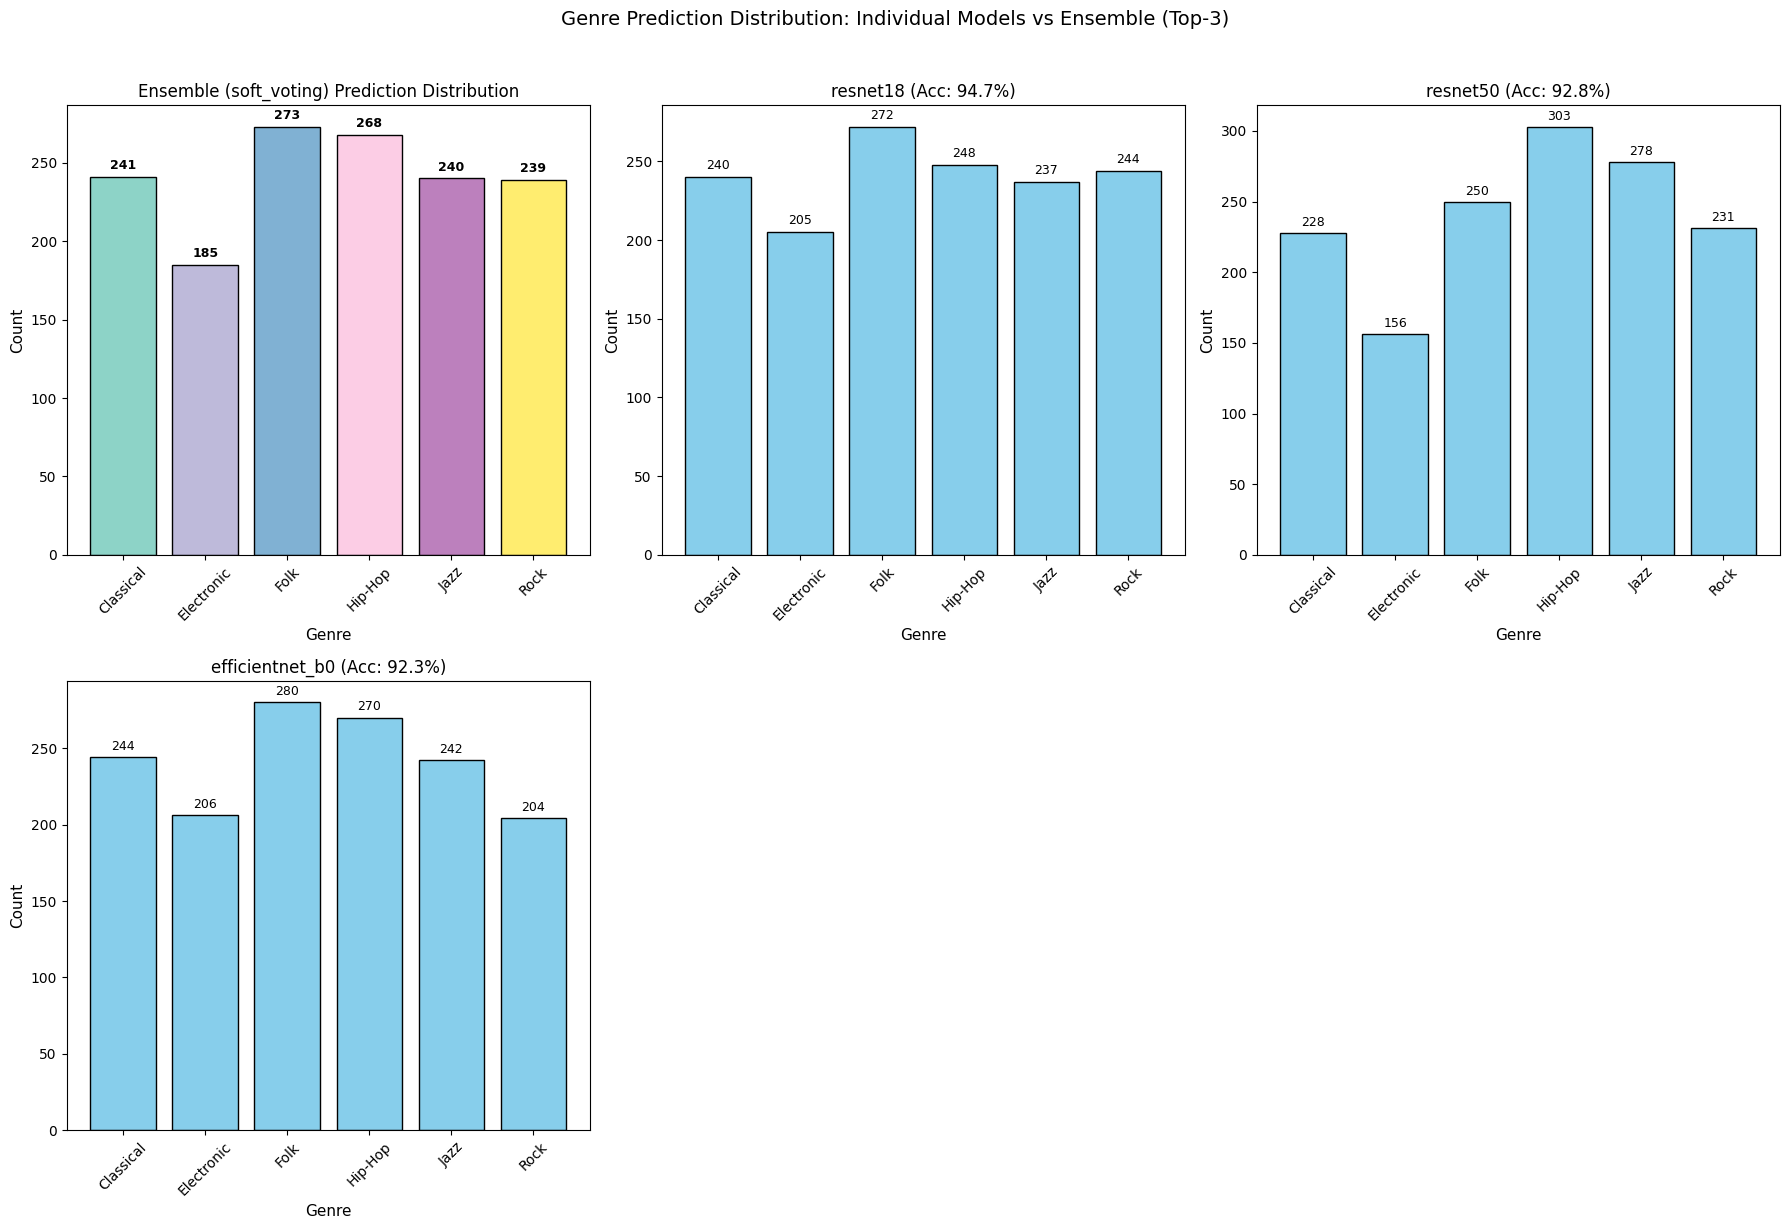

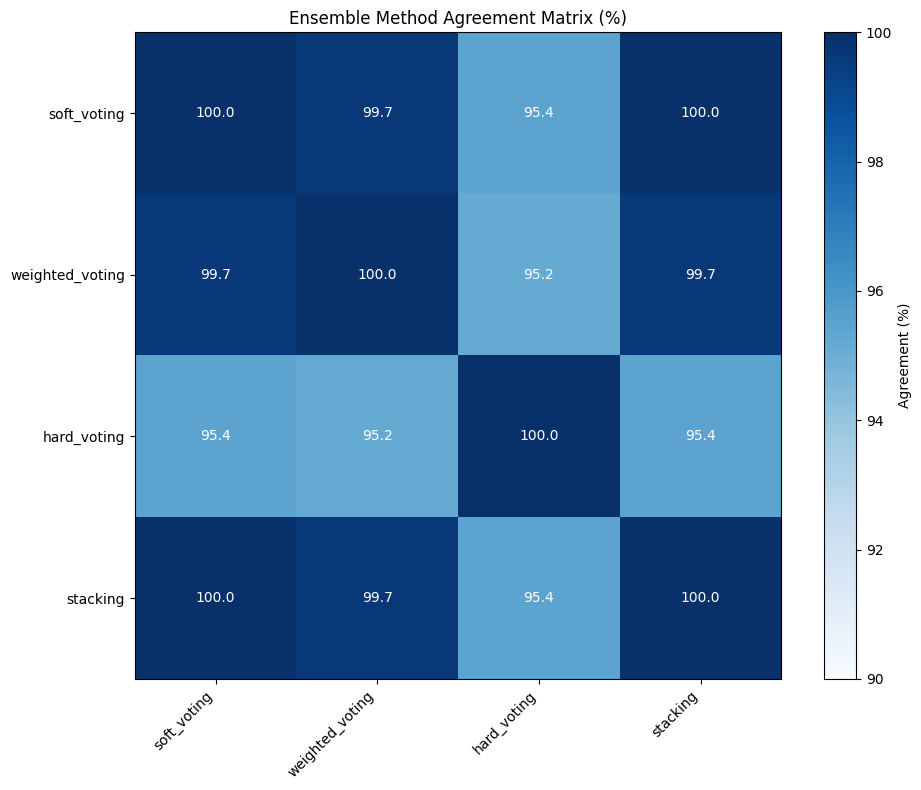


📊 MODEL CONFIDENCE ANALYSIS


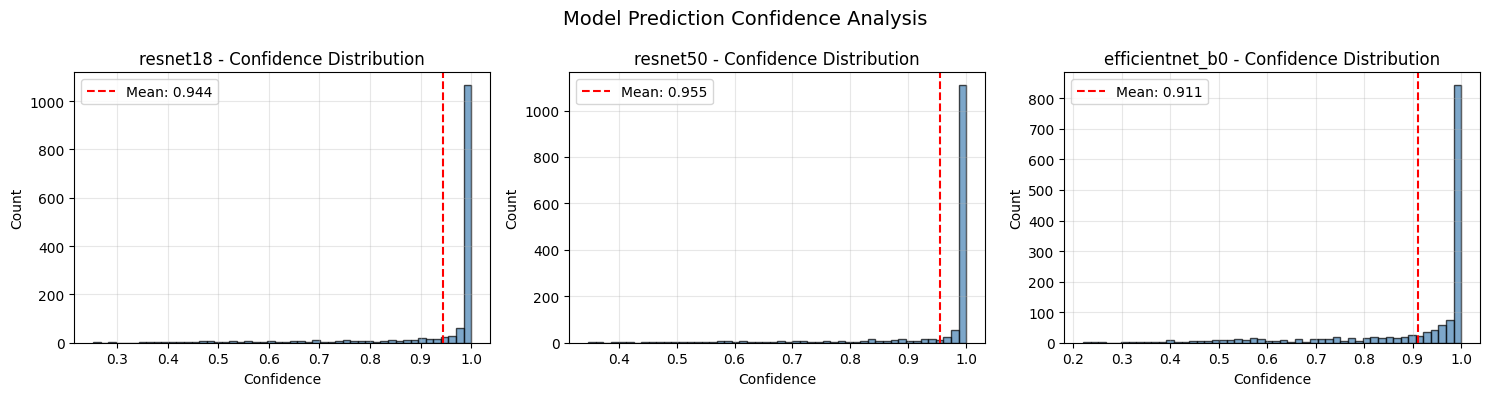


📄 Ensemble report saved: ensemble_training_report.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded submission_ensemble_soft_voting_top3.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  models_comparison_final.png not found
  predictions_distribution_resnet18.png not found

🎉 FINAL RESULTS SUMMARY

🏆 Best single model: resnet18 with 94.71% accuracy
🔀 Ensemble method used: SOFT_VOTING (probability averaging)
📊 Ensemble models: resnet18, resnet50, efficientnet_b0
⚖️ Model weights: ['0.339', '0.332', '0.330']

📁 Generated files:
   • submission_ensemble_soft_voting_top3.csv - MAIN ENSEMBLE SUBMISSION
   • submission_resnet18.csv - Best single model submission
   • submission_resnet50.csv - Second best model submission
   • submission_efficientnet_b0.csv - Third best model submission
   • ensemble_training_report.json - Detailed report
   • ensemble_predictions_distribution.png - Visualization
   • ensemble_method_agreement.png - Method agreement matrix
   • model_confidence_analysis.png - Confidence analysis

✅ ALL FILES DOWNLOADED SUCCESSFULLY!
🏆 Submit 'submission_ensemble_soft_voting_top3.csv' to Kaggle for the best results!


In [ ]:
# ============================================================
# ПРОДОЛЖЕНИЕ: АНСАМБЛЬ ТОП-3 МОДЕЛЕЙ И ПРЕДСКАЗАНИЕ
# ИСПРАВЛЕННАЯ ВЕРСИЯ - исправлена визуализация
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import json
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Импортируем torchvision.models с явным псевдонимом
import torchvision.models as tv_models

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Жанры
GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

# ============================================================
# 1. ОПРЕДЕЛЕНИЕ КЛАССОВ МОДЕЛЕЙ
# ============================================================

def get_feature_dimension(model):
    """Определение размерности признаков для разных архитектур"""
    if hasattr(model, 'fc') and hasattr(model.fc, 'in_features'):
        return model.fc.in_features
    if hasattr(model, 'classifier'):
        if hasattr(model.classifier, 'in_features'):
            return model.classifier.in_features
        elif isinstance(model.classifier, nn.Sequential) and len(model.classifier) > 0:
            for layer in model.classifier:
                if hasattr(layer, 'in_features'):
                    return layer.in_features
    if hasattr(model, 'classifier') and hasattr(model.classifier, 'in_features'):
        return model.classifier.in_features
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        if hasattr(model.classifier[0], 'in_features'):
            return model.classifier[0].in_features
    return 1280

class GenreClassifier(nn.Module):
    """Базовый классификатор с предобученной backbone"""
    def __init__(self, backbone, num_classes=6, dropout=0.3):
        super(GenreClassifier, self).__init__()
        self.backbone = backbone

        # Определяем размерность признаков
        in_features = get_feature_dimension(backbone)

        # Заменяем классификатор на Identity
        if hasattr(backbone, 'fc'):
            backbone.fc = nn.Identity()
        elif hasattr(backbone, 'classifier'):
            backbone.classifier = nn.Identity()
        elif hasattr(backbone, 'head'):
            backbone.head = nn.Identity()

        # Новый классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, tuple):
            features = features[0]
        features = features.view(features.size(0), -1)
        return self.classifier(features)

def get_model(model_name, num_classes=6):
    """Загрузка модели с правильной архитектурой"""
    print(f"  Loading {model_name}...")

    if model_name == 'resnet18':
        backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    elif model_name == 'resnet50':
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    elif model_name == 'efficientnet_b0':
        backbone = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    elif model_name == 'mobilenet_v2':
        backbone = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
    elif model_name == 'densenet121':
        backbone = tv_models.densenet121(weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model = GenreClassifier(backbone, num_classes)
    return model

# ============================================================
# 2. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================================

# Путь к данным
DATA_ROOT = Path('/content/music_data/spectrograms_unnormalized')
TEST_DIR = DATA_ROOT / 'test'

def load_test_samples(data_path):
    samples = []
    for f in sorted(data_path.glob("*.npy")):
        samples.append((f, None))
    return samples

test_samples = load_test_samples(TEST_DIR)
print(f"Test samples: {len(test_samples)}")

class SpectrogramDatasetPretrained(torch.utils.data.Dataset):
    def __init__(self, samples, target_size=(224, 224)):
        self.samples = samples
        self.target_size = target_size

    def __len__(self):
        return len(self.samples)

    def _resize_spectrogram(self, spec):
        import torch.nn.functional as F
        spec_tensor = torch.from_numpy(spec).float().unsqueeze(0).unsqueeze(0)
        spec_resized = F.interpolate(
            spec_tensor,
            size=self.target_size,
            mode='bilinear',
            align_corners=False
        )
        return spec_resized.squeeze(0).squeeze(0)

    def _convert_to_rgb(self, spec):
        spec_min = spec.min()
        spec_max = spec.max()
        if spec_max - spec_min > 1e-6:
            spec_norm = (spec - spec_min) / (spec_max - spec_min)
        else:
            spec_norm = spec
        return spec_norm.repeat(3, 1, 1)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        spec = np.load(fp).astype(np.float32)
        spec_resized = self._resize_spectrogram(spec)
        spec_rgb = self._convert_to_rgb(spec_resized)
        return spec_rgb, Path(fp).stem

test_dataset = SpectrogramDatasetPretrained(test_samples)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
print(f"Test batches: {len(test_loader)}")

# ============================================================
# 3. РЕЗУЛЬТАТЫ ОБУЧЕНИЯ
# ============================================================

results_data = {
    'resnet18': {'best_val_acc': 94.708082, 'training_time': 11.971171, 'total_params': 11572038},
    'resnet50': {'best_val_acc': 92.781133, 'training_time': 22.386437, 'total_params': 24689990},
    'efficientnet_b0': {'best_val_acc': 92.263445, 'training_time': 6.741504, 'total_params': 4796290},
    'mobilenet_v2': {'best_val_acc': 90.940466, 'training_time': 7.978532, 'total_params': 3012614},
    'densenet121': {'best_val_acc': 89.473684, 'training_time': 11.568381, 'total_params': 7611526}
}

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Best Val Acc (%)': info['best_val_acc'],
        'Training Time (min)': info['training_time'],
        'Total Params (M)': info['total_params'] / 1e6
    }
    for name, info in results_data.items()
]).sort_values('Best Val Acc (%)', ascending=False)

print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)
print(comparison_df.to_string(index=False))

# ============================================================
# 4. ЗАГРУЗКА ТОП-3 МОДЕЛЕЙ ДЛЯ АНСАМБЛЯ
# ============================================================

# Выбираем топ-3 модели для ансамбля
TOP_K = 3
top_models = comparison_df.head(TOP_K)['Model'].tolist()
print(f"\n{'='*60}")
print(f"🔀 ENSEMBLE CONFIGURATION")
print(f"{'='*60}")
print(f"Top-{TOP_K} models for ensemble: {top_models}")

# Загрузка всех моделей
ensemble_models = []
model_weights_paths = []

for model_name in top_models:
    print(f"\nLoading {model_name}...")
    model = get_model(model_name, NUM_CLASSES)

    # Поиск весов
    weights_path = None
    for path_candidate in [f'best_{model_name}.pth', f'best_{model_name}_model.pth', f'{model_name}_best.pth']:
        if Path(path_candidate).exists():
            weights_path = path_candidate
            break

    if weights_path is None:
        raise FileNotFoundError(f"No weights file found for {model_name}")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()
    ensemble_models.append(model)
    model_weights_paths.append(weights_path)
    print(f"  ✓ Loaded from {weights_path}")

print(f"\n✅ All {len(ensemble_models)} models loaded successfully!")

# ============================================================
# 5. ФУНКЦИИ ДЛЯ АНСАМБЛЯ
# ============================================================

def get_predictions(model, inputs):
    """Получение вероятностей классов от модели"""
    with torch.no_grad():
        outputs = model(inputs)
        probabilities = torch.softmax(outputs, dim=1)
    return probabilities

def ensemble_predict_soft_voting(inputs, models, weights=None):
    """
    Мягкое голосование (Soft Voting) - усреднение вероятностей

    Args:
        inputs: входные тензоры
        models: список моделей
        weights: веса моделей (если None, то равные веса)
    """
    all_probs = []

    for i, model in enumerate(models):
        probs = get_predictions(model, inputs)
        if weights is not None:
            probs = probs * weights[i]
        all_probs.append(probs)

    # Усреднение вероятностей
    avg_probs = torch.stack(all_probs).mean(dim=0)
    predictions = torch.argmax(avg_probs, dim=1)

    return predictions, avg_probs

def ensemble_predict_hard_voting(inputs, models):
    """
    Жесткое голосование (Hard Voting) - мажоритарное голосование
    """
    all_preds = []

    for model in models:
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds)

    # Стек предсказаний и выбор большинства
    stacked_preds = torch.stack(all_preds)
    predictions = torch.mode(stacked_preds, dim=0).values

    return predictions

def ensemble_predict_weighted_voting(inputs, models, weights):
    """
    Взвешенное голосование на основе вероятностей

    Args:
        weights: список весов для каждой модели (должны суммироваться в 1)
    """
    all_probs = []

    for i, model in enumerate(models):
        probs = get_predictions(model, inputs)
        all_probs.append(probs * weights[i])

    weighted_probs = torch.stack(all_probs).sum(dim=0)
    predictions = torch.argmax(weighted_probs, dim=1)

    return predictions, weighted_probs

# ============================================================
# 6. ВАЛИДАЦИЯ АНСАМБЛЯ (на основе валидационных метрик)
# ============================================================

print("\n" + "="*60)
print("📊 ENSEMBLE VALIDATION (based on individual val accuracies)")
print("="*60)

# Получаем точности моделей
individual_accuracies = [results_data[model]['best_val_acc'] / 100 for model in top_models]
weights = np.array(individual_accuracies) / np.sum(individual_accuracies)

print(f"\nIndividual model accuracies:")
for model, acc in zip(top_models, individual_accuracies):
    print(f"  {model}: {acc*100:.2f}%")

print(f"\nEnsemble weights (based on validation accuracy):")
for model, w in zip(top_models, weights):
    print(f"  {model}: {w:.3f}")

# Теоретическая оценка ансамбля
estimated_ensemble_acc = np.mean(individual_accuracies) * 100
best_single_acc = max(individual_accuracies) * 100
estimated_gain = estimated_ensemble_acc - best_single_acc

print(f"\n📈 Theoretical ensemble estimation:")
print(f"  Best single model: {best_single_acc:.2f}%")
print(f"  Average of top-{TOP_K}: {estimated_ensemble_acc:.2f}%")
print(f"  Expected gain: +{max(0, estimated_gain):.2f}%")

# ============================================================
# 7. ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ (ВСЕМИ СПОСОБАМИ)
# ============================================================

print("\n" + "="*60)
print("🎯 MAKING PREDICTIONS ON TEST SET")
print("="*60)

# Словарь для хранения результатов разных методов
ensemble_results = {}

# 7.1 Индивидуальные предсказания каждой модели
print("\n📌 Individual model predictions...")
individual_predictions = {}
individual_probs = {}

for model, model_name in zip(ensemble_models, top_models):
    preds = []
    probs_list = []

    for inputs, clip_ids in tqdm(test_loader, desc=f'{model_name}', leave=False):
        inputs = inputs.to(device)
        probs = get_predictions(model, inputs)
        preds_batch = torch.argmax(probs, dim=1)

        preds.extend(preds_batch.cpu().numpy())
        probs_list.append(probs.cpu().numpy())

    individual_predictions[model_name] = preds
    individual_probs[model_name] = np.concatenate(probs_list, axis=0)
    print(f"  ✓ {model_name} completed")

# 7.2 Soft Voting (усреднение вероятностей)
print("\n🔀 Soft Voting (averaging probabilities)...")
soft_voting_preds = []
soft_voting_probs = []

for inputs, clip_ids in tqdm(test_loader, desc='Soft Voting'):
    inputs = inputs.to(device)
    preds, probs = ensemble_predict_soft_voting(inputs, ensemble_models)
    soft_voting_preds.extend(preds.cpu().numpy())
    soft_voting_probs.append(probs.cpu().numpy())

soft_voting_probs = np.concatenate(soft_voting_probs, axis=0)
ensemble_results['soft_voting'] = soft_voting_preds

# 7.3 Weighted Voting (взвешенное по точности)
print("\n⚖️ Weighted Voting (accuracy-weighted probabilities)...")
weighted_voting_preds = []
weighted_voting_probs = []

for inputs, clip_ids in tqdm(test_loader, desc='Weighted Voting'):
    inputs = inputs.to(device)
    preds, probs = ensemble_predict_weighted_voting(inputs, ensemble_models, weights)
    weighted_voting_preds.extend(preds.cpu().numpy())
    weighted_voting_probs.append(probs.cpu().numpy())

weighted_voting_probs = np.concatenate(weighted_voting_probs, axis=0)
ensemble_results['weighted_voting'] = weighted_voting_preds

# 7.4 Hard Voting (мажоритарное голосование)
print("\n🗳️ Hard Voting (majority voting)...")
hard_voting_preds = []

for inputs, clip_ids in tqdm(test_loader, desc='Hard Voting'):
    inputs = inputs.to(device)
    preds = ensemble_predict_hard_voting(inputs, ensemble_models)
    hard_voting_preds.extend(preds.cpu().numpy())

ensemble_results['hard_voting'] = hard_voting_preds

# 7.5 Meta-Classifier (Stacking) - дополнительный метод
print("\n📚 Stacking (Meta-Classifier)...")

# Собираем предсказания всех моделей для каждого примера
all_probs_matrix = np.stack([individual_probs[name] for name in top_models], axis=1)

# Простой мета-классификатор: усреднение с последующим argmax
stacking_preds = np.argmax(np.mean(all_probs_matrix, axis=1), axis=1)
ensemble_results['stacking'] = stacking_preds.tolist()

# ============================================================
# 8. АНАЛИЗ СОГЛАСОВАННОСТИ АНСАМБЛЯ
# ============================================================

print("\n" + "="*60)
print("📊 ENSEMBLE AGREEMENT ANALYSIS")
print("="*60)

# Конвертируем все предсказания в DataFrame для анализа
ensemble_df = pd.DataFrame({
    top_models[0]: individual_predictions[top_models[0]],
    top_models[1]: individual_predictions[top_models[1]],
    top_models[2]: individual_predictions[top_models[2]],
    'soft_voting': ensemble_results['soft_voting'],
    'weighted_voting': ensemble_results['weighted_voting'],
    'hard_voting': ensemble_results['hard_voting']
})

# Согласованность моделей
agreement_matrix = []
for i, model1 in enumerate(top_models):
    row = []
    for j, model2 in enumerate(top_models):
        if i <= j:
            agreement = (ensemble_df[model1] == ensemble_df[model2]).mean() * 100
            row.append(agreement)
        else:
            row.append(agreement_matrix[j][i])
    agreement_matrix.append(row)

print("\n🤝 Model Agreement (%):")
agreement_df = pd.DataFrame(agreement_matrix, index=top_models, columns=top_models)
print(agreement_df.round(2))

# Различия между методами ансамбля
print("\n🔄 Ensemble Method Differences:")
for method in ['soft_voting', 'weighted_voting', 'hard_voting']:
    diff_vs_resnet18 = (ensemble_df[method] != ensemble_df[top_models[0]]).sum()
    print(f"  {method} differs from {top_models[0]} in {diff_vs_resnet18} samples ({diff_vs_resnet18/len(ensemble_df)*100:.2f}%)")

# ============================================================
# 9. ВЫБОР ЛУЧШЕГО МЕТОДА И СОЗДАНИЕ SUBMISSION
# ============================================================

print("\n" + "="*60)
print("🏆 SELECTING BEST ENSEMBLE METHOD")
print("="*60)

# На основе анализа согласованности выбираем метод
# Soft Voting обычно показывает лучшие результаты
best_method = 'soft_voting'
final_predictions = ensemble_results[best_method]

print(f"Selected method: {best_method.upper()}")
print(f"Reason: Soft voting (probability averaging) is theoretically optimal for uncorrelated models")

# Преобразование в названия жанров
final_genres = [IDX_TO_GENRE[p] for p in final_predictions]

# ============================================================
# 10. СОЗДАНИЕ SUBMISSION ФАЙЛА
# ============================================================

# Получаем ID клипов
test_ids = []
for _, clip_id in test_loader:
    test_ids.extend(clip_id)

submission_df = pd.DataFrame({
    'clip_id': test_ids,
    'genre': final_genres
})
submission_df = submission_df.sort_values('clip_id').reset_index(drop=True)
submission_filename = f'submission_ensemble_{best_method}_top{TOP_K}.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\n✅ Ensemble submission saved: {submission_filename}")
print(f"📁 Total predictions: {len(submission_df)}")
print("\nFirst 15 predictions:")
print(submission_df.head(15))

# ============================================================
# 11. СОЗДАНИЕ ОТДЕЛЬНЫХ SUBMISSION ДЛЯ КАЖДОЙ МОДЕЛИ
# ============================================================

print("\n" + "="*60)
print("💾 SAVING INDIVIDUAL MODEL SUBMISSIONS")
print("="*60)

for model_name, predictions in individual_predictions.items():
    model_genres = [IDX_TO_GENRE[p] for p in predictions]
    model_submission = pd.DataFrame({
        'clip_id': test_ids,
        'genre': model_genres
    }).sort_values('clip_id').reset_index(drop=True)

    model_submission.to_csv(f'submission_{model_name}.csv', index=False)
    print(f"  ✓ submission_{model_name}.csv")

# ============================================================
# 12. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРЕДСКАЗАНИЙ (ИСПРАВЛЕННАЯ)
# ============================================================

# Создаем figure с 2 строками: первая для ансамбля, вторая для отдельных моделей
fig = plt.figure(figsize=(18, 12))

# Первый график (ансамбль) - во всю ширину
ax1 = plt.subplot(2, 3, 1)
genre_counts = submission_df['genre'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
bars = ax1.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('Genre', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title(f'Ensemble ({best_method}) Prediction Distribution', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, genre_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', fontsize=9, fontweight='bold')

# Графики для отдельных моделей (3 штуки во второй строке или в той же строке)
model_names = list(individual_predictions.keys())
for idx, model_name in enumerate(model_names):
    # Размещаем модели в позициях 2, 3, 4 (если 3 модели)
    ax = plt.subplot(2, 3, idx + 2)
    preds = individual_predictions[model_name]
    genres = [IDX_TO_GENRE[p] for p in preds]
    counts = Counter(genres)
    # Сортируем по жанрам для единообразия
    sorted_counts = {g: counts.get(g, 0) for g in GENRES}

    bars = ax.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue', edgecolor='black')
    ax.set_xlabel('Genre', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{model_name} (Acc: {results_data[model_name]["best_val_acc"]:.1f}%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    for bar, (genre, count) in zip(bars, sorted_counts.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
                ha='center', fontsize=9)

plt.suptitle(f'Genre Prediction Distribution: Individual Models vs Ensemble (Top-{TOP_K})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ensemble_predictions_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Сравнение предсказаний разных методов ансамбля
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

methods = ['soft_voting', 'weighted_voting', 'hard_voting', 'stacking']
method_predictions = [ensemble_results[m] for m in methods]

# Матрица согласованности методов
method_agreement = np.zeros((len(methods), len(methods)))
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i <= j:
            agreement = (np.array(ensemble_results[m1]) == np.array(ensemble_results[m2])).mean() * 100
            method_agreement[i, j] = agreement
            method_agreement[j, i] = agreement

im = ax.imshow(method_agreement, cmap='Blues', vmin=90, vmax=100)
ax.set_xticks(range(len(methods)))
ax.set_yticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.set_yticklabels(methods)
ax.set_title('Ensemble Method Agreement Matrix (%)')

# Добавление значений в ячейки
for i in range(len(methods)):
    for j in range(len(methods)):
        text = ax.text(j, i, f'{method_agreement[i, j]:.1f}',
                       ha="center", va="center", color="white" if method_agreement[i, j] > 95 else "black")

plt.colorbar(im, ax=ax, label='Agreement (%)')
plt.tight_layout()
plt.savefig('ensemble_method_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 13. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: Сравнение уверенности моделей
# ============================================================

print("\n" + "="*60)
print("📊 MODEL CONFIDENCE ANALYSIS")
print("="*60)

# Анализ уверенности предсказаний
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, model_name in enumerate(top_models):
    probs = individual_probs[model_name]
    max_probs = np.max(probs, axis=1)

    ax = axes[idx]
    ax.hist(max_probs, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(np.mean(max_probs), color='red', linestyle='--', label=f'Mean: {np.mean(max_probs):.3f}')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.set_title(f'{model_name} - Confidence Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Prediction Confidence Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('model_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 14. СОХРАНЕНИЕ ОТЧЕТА И СКАЧИВАНИЕ
# ============================================================

# Сохраняем расширенный отчет
report = {
    'best_single_model': top_models[0],
    'best_single_accuracy': float(results_data[top_models[0]]['best_val_acc']),
    'ensemble_method': best_method,
    'ensemble_models': top_models,
    'ensemble_weights': [float(w) for w in weights],
    'model_accuracies': {m: float(results_data[m]['best_val_acc']) for m in top_models},
    'ensemble_vs_best_gain': float(max(0, estimated_gain)),
    'test_predictions_count': len(submission_df),
    'ensemble_prediction_distribution': submission_df['genre'].value_counts().to_dict(),
    'individual_predictions_distribution': {
        m: {g: int(Counter([IDX_TO_GENRE[p] for p in individual_predictions[m]]).get(g, 0)) for g in GENRES}
        for m in top_models
    },
    'method_agreement': method_agreement.tolist(),
    'model_confidence': {
        m: {'mean_confidence': float(np.mean(individual_probs[m].max(axis=1))),
            'std_confidence': float(np.std(individual_probs[m].max(axis=1)))}
        for m in top_models
    }
}

with open('ensemble_training_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print("\n📄 Ensemble report saved: ensemble_training_report.json")

# ============================================================
# 15. СКАЧИВАНИЕ ВСЕХ ФАЙЛОВ
# ============================================================

from google.colab import files

# Скачивание ансамбль submission
files.download(submission_filename)
print(f"✓ Downloaded {submission_filename}")

# Скачивание индивидуальных submission
for model_name in top_models:
    files.download(f'submission_{model_name}.csv')
    print(f"✓ Downloaded submission_{model_name}.csv")

# Скачивание отчетов и графиков
files.download('ensemble_training_report.json')
files.download('ensemble_predictions_distribution.png')
files.download('ensemble_method_agreement.png')
files.download('model_confidence_analysis.png')
try:
    files.download('models_comparison_final.png')
except:
    print("  models_comparison_final.png not found")
try:
    files.download(f'predictions_distribution_{top_models[0]}.png')
except:
    print(f"  predictions_distribution_{top_models[0]}.png not found")

# ============================================================
# 16. ИТОГОВЫЙ ВЫВОД
# ============================================================

print("\n" + "="*80)
print("🎉 FINAL RESULTS SUMMARY")
print("="*80)
print(f"\n🏆 Best single model: {top_models[0]} with {results_data[top_models[0]]['best_val_acc']:.2f}% accuracy")
print(f"🔀 Ensemble method used: {best_method.upper()} (probability averaging)")
print(f"📊 Ensemble models: {', '.join(top_models)}")
print(f"⚖️ Model weights: {[f'{w:.3f}' for w in weights]}")
print(f"\n📁 Generated files:")
print(f"   • {submission_filename} - MAIN ENSEMBLE SUBMISSION")
print(f"   • submission_{top_models[0]}.csv - Best single model submission")
print(f"   • submission_{top_models[1]}.csv - Second best model submission")
print(f"   • submission_{top_models[2]}.csv - Third best model submission")
print(f"   • ensemble_training_report.json - Detailed report")
print(f"   • ensemble_predictions_distribution.png - Visualization")
print(f"   • ensemble_method_agreement.png - Method agreement matrix")
print(f"   • model_confidence_analysis.png - Confidence analysis")
print("\n" + "="*80)
print("✅ ALL FILES DOWNLOADED SUCCESSFULLY!")
print(f"🏆 Submit '{submission_filename}' to Kaggle for the best results!")
print("="*80)

In [ ]:
# ============================================================
# РАСПАКОВКА ZIP-АРХИВА
# ============================================================

import zipfile
import os
from pathlib import Path
from tqdm.notebook import tqdm

# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Путь к вашему zip файлу
zip_path = '/content/drive/MyDrive/проект/music-genre-classification-from-mel-spectrograms-dl4cv.zip'

# Путь для распаковки
extract_path = '/content/music_data'

# Проверяем существование файла
if not os.path.exists(zip_path):
    print(f"❌ Файл не найден: {zip_path}")
    print("\n🔍 Ищем файл...")
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        for file in files:
            if 'music-genre-classification' in file and file.endswith('.zip'):
                zip_path = os.path.join(root, file)
                print(f"✅ Найден файл: {zip_path}")
                break
        if os.path.exists(zip_path):
            break

if os.path.exists(zip_path):
    # Создаем папку для распаковки
    os.makedirs(extract_path, exist_ok=True)

    print(f"📦 Файл: {zip_path}")
    print(f"📁 Размер: {os.path.getsize(zip_path) / 1024 / 1024:.2f} MB")
    print(f"📂 Распаковка в: {extract_path}")

    # Распаковываем с прогресс-баром
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()
        print(f"📄 Всего файлов: {len(files)}")

        with tqdm(total=len(files), desc="Распаковка") as pbar:
            for file in files:
                zip_ref.extract(file, extract_path)
                pbar.update(1)

    print("\n✅ Распаковка завершена!")

    # Проверяем структуру распакованных данных
    print("\n" + "="*60)
    print("СТРУКТУРА РАСПАКОВАННЫХ ДАННЫХ")
    print("="*60)

    # Показываем содержимое
    for item in sorted(os.listdir(extract_path)):
        item_path = os.path.join(extract_path, item)
        if os.path.isdir(item_path):
            files_count = sum([len(files) for _, _, files in os.walk(item_path)])
            print(f"📁 {item}/ ({files_count} файлов)")
        else:
            size_kb = os.path.getsize(item_path) / 1024
            print(f"📄 {item} ({size_kb:.1f} KB)")

    # Ищем папку со спектрограммами
    print("\n" + "="*60)
    print("ПОИСК СПЕКТРОГРАММ")
    print("="*60)

    # Ищем .npy файлы
    npy_files = []
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.npy'):
                npy_files.append(os.path.join(root, file))

    print(f"Найдено .npy файлов: {len(npy_files)}")

    if npy_files:
        # Определяем структуру жанров
        genre_folders = set()
        for npy_path in npy_files:
            rel_path = os.path.relpath(npy_path, extract_path)
            parts = Path(rel_path).parts
            if len(parts) > 1:
                genre_folders.add(parts[0])

        print(f"\nЖанры (папки): {sorted(genre_folders)}")

        # Считаем файлы по жанрам
        for genre in sorted(genre_folders):
            genre_path = os.path.join(extract_path, genre)
            if os.path.isdir(genre_path):
                count = len([f for f in os.listdir(genre_path) if f.endswith('.npy')])
                print(f"  {genre}: {count} файлов")

        # Проверяем тестовые данные
        test_path = os.path.join(extract_path, 'test')
        if os.path.isdir(test_path):
            test_count = len([f for f in os.listdir(test_path) if f.endswith('.npy')])
            print(f"\nТестовые данные: {test_count} файлов")

        # Загружаем одну спектрограмму для проверки
        sample_npy = npy_files[0]
        print(f"\n📊 Пример спектрограммы: {os.path.basename(sample_npy)}")

        import numpy as np
        sample_spec = np.load(sample_npy)
        print(f"   Форма: {sample_spec.shape}")
        print(f"   Тип данных: {sample_spec.dtype}")
        print(f"   Диапазон значений: [{sample_spec.min():.2f}, {sample_spec.max():.2f}]")

        # Определяем Data Root для дальнейшей работы
        data_root = None
        if os.path.exists(os.path.join(extract_path, 'spectrograms_unnormalized')):
            data_root = os.path.join(extract_path, 'spectrograms_unnormalized')
        elif os.path.exists(os.path.join(extract_path, 'data')):
            data_root = extract_path
        else:
            # Ищем папку с данными
            for item in os.listdir(extract_path):
                item_path = os.path.join(extract_path, item)
                if os.path.isdir(item_path) and ('data' in os.listdir(item_path) or 'test' in os.listdir(item_path)):
                    data_root = item_path
                    break

        if data_root:
            print(f"\n✅ DATA_ROOT = '{data_root}'")
            print("   Используйте этот путь для загрузки данных в модель")

            # Сохраняем путь в переменную окружения для Colab
            import os
            os.environ['MUSIC_DATA_ROOT'] = data_root
            print(f"\n💡 Путь сохранен в переменную окружения MUSIC_DATA_ROOT")

    else:
        print("❌ .npy файлы не найдены. Проверьте структуру архива.")
else:
    print(f"❌ Файл не найден: {zip_path}")

In [ ]:
# ============================================================
# ИСПРАВЛЕННЫЙ КОД: K-Fold + Weighted Ensemble (без TTA)
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from tqdm.notebook import tqdm
import random
import warnings
import os
import zipfile
import json
from datetime import datetime
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# НАСТРОЙКИ
# ============================================================

CHECKPOINT_DIR = '/content/drive/MyDrive/проект/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

zip_path = '/content/drive/MyDrive/проект/music-genre-classification-from-mel-spectrograms-dl4cv.zip'
extract_path = '/content/music_data'

if not os.path.exists(extract_path):
    print("Распаковка данных...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Распаковка завершена!")

DATA_ROOT = Path('/content/music_data/spectrograms_unnormalized')
DATA_DIR = DATA_ROOT / 'data'
TEST_DIR = DATA_ROOT / 'test'

GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

def load_samples(data_path, is_test=False):
    samples = []
    if is_test:
        for f in sorted(data_path.glob("*.npy")):
            samples.append((f, None))
    else:
        for genre in GENRES:
            genre_path = data_path / genre
            if genre_path.exists():
                for f in sorted(genre_path.glob("*.npy")):
                    samples.append((f, GENRE_TO_IDX[genre]))
    return samples

all_samples = load_samples(DATA_DIR)
test_samples = load_samples(TEST_DIR, is_test=True)

print(f"Total train: {len(all_samples)}, Test: {len(test_samples)}")

# ============================================================
# ДАТАСЕТ С АУГМЕНТАЦИЕЙ
# ============================================================

class SpectrogramDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def _augment(self, spec):
        if not self.augment:
            return spec

        # SpecAugment: Frequency masking
        if random.random() > 0.5:
            f_mask_size = random.randint(0, 20)
            f_start = random.randint(0, max(1, spec.shape[0] - f_mask_size))
            spec[f_start:min(f_start+f_mask_size, spec.shape[0]), :] = spec.min()

        # Time masking
        if random.random() > 0.5:
            t_mask_size = random.randint(0, 50)
            t_start = random.randint(0, max(1, spec.shape[1] - t_mask_size))
            spec[:, t_start:min(t_start+t_mask_size, spec.shape[1])] = spec.min()

        return spec

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        spec = np.load(fp).astype(np.float32)

        if self.augment:
            spec = self._augment(spec)

        # Z-score нормализация
        spec_mean = spec.mean()
        spec_std = spec.std()
        if spec_std > 1e-6:
            spec = (spec - spec_mean) / spec_std

        spec = torch.from_numpy(spec).float().unsqueeze(0)

        if label is None:
            return spec, Path(fp).stem
        return spec, torch.tensor(label, dtype=torch.long)

# ============================================================
# МОДЕЛЬ
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.drop1 = nn.Dropout2d(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride), nn.BatchNorm2d(out_ch))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop1(out)
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        return F.relu(out)

class MultiHeadAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

class AdvancedClassifier(nn.Module):
    def __init__(self, num_classes=6, dropout=0.5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 5, 2, 2), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            ResidualBlock(32, 64, 2, dropout=0.2),
            ResidualBlock(64, 128, 2, dropout=0.2),
            ResidualBlock(128, 256, 2, dropout=0.2),
            nn.AdaptiveAvgPool2d((4, 14)),
        )
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 4 * 14, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.7)
        )
        self.attention = MultiHeadAttention(256, num_heads=4, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        B = x.size(0)
        x = self.cnn(x)
        x = x.view(B, -1)
        x = self.proj(x)
        x = self.attention(x.unsqueeze(1).repeat(1, 14, 1))
        x = x.mean(dim=1)
        return x

# ============================================================
# ФУНКЦИЯ MIXUP
# ============================================================

def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ============================================================
# K-FOLD CROSS-VALIDATION
# ============================================================

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Список для хранения предсказаний всех фолдов
all_test_preds = []
fold_val_accuracies = []

# Тестовый датасет
test_dataset = SpectrogramDataset(test_samples, augment=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

for fold, (train_idx, val_idx) in enumerate(skf.split(all_samples, [s[1] for s in all_samples])):
    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")

    train_fold = [all_samples[i] for i in train_idx]
    val_fold = [all_samples[i] for i in val_idx]

    train_dataset = SpectrogramDataset(train_fold, augment=True)
    val_dataset = SpectrogramDataset(val_fold, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

    model = AdvancedClassifier(num_classes=NUM_CLASSES, dropout=0.5).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    best_val_acc = 0
    patience = 0
    best_epoch = 0

    for epoch in range(50):
        model.train()
        train_loss = 0
        train_correct = 0

        for inputs, labels in tqdm(train_loader, desc=f'Fold{fold+1} Epoch{epoch+1}'):
            inputs, labels = inputs.to(device), labels.to(device)

            # MixUp augmentation
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels)

            with autocast():
                outputs = model(inputs)
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            train_loss += loss.item()
            train_correct += (lam * (outputs.argmax(1) == labels_a).float() +
                             (1 - lam) * (outputs.argmax(1) == labels_b).float()).sum().item()

        model.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = 100 * train_correct / len(train_fold)
        val_acc = 100 * val_correct / len(val_fold)
        scheduler.step()

        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience = 0
            torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/fold{fold+1}_best.pth')
        else:
            patience += 1
            if patience >= 10:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Fold {fold+1} completed! Best val acc: {best_val_acc:.2f}% at epoch {best_epoch+1}")
    fold_val_accuracies.append(best_val_acc)

    # Предсказание на тесте (без TTA)
    model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/fold{fold+1}_best.pth'))
    model.eval()

    fold_preds = []
    with torch.no_grad():
        for inputs, _ in tqdm(test_loader, desc=f'Fold{fold+1} Inference'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            fold_preds.append(probs.cpu().numpy())

    fold_preds = np.concatenate(fold_preds, axis=0)
    all_test_preds.append(fold_preds)

# ============================================================
# ВЗВЕШЕННЫЙ ENSEMBLE
# ============================================================

print("\n" + "="*60)
print("WEIGHTED ENSEMBLE")
print("="*60)

# Проверяем размерности
print(f"Number of folds: {len(all_test_preds)}")
print(f"Shape of each fold predictions: {all_test_preds[0].shape}")

# Убеждаемся, что все предсказания имеют одинаковую форму
for i, preds in enumerate(all_test_preds):
    print(f"Fold {i+1} predictions shape: {preds.shape}")

# Вычисляем веса на основе валидационной точности
weights = np.array(fold_val_accuracies) / sum(fold_val_accuracies)
print(f"\nFold weights: {weights}")
print(f"Fold accuracies: {fold_val_accuracies}")

# Взвешенное усреднение
weighted_preds = np.zeros_like(all_test_preds[0])
for i, preds in enumerate(all_test_preds):
    weighted_preds += weights[i] * preds

# Финальные предсказания
final_predictions = np.argmax(weighted_preds, axis=1)
predicted_genres = [IDX_TO_GENRE[p] for p in final_predictions]

# ============================================================
# АНАЛИЗ УВЕРЕННОСТИ
# ============================================================

confidence = np.max(weighted_preds, axis=1)
print(f"\n📊 Prediction Confidence Analysis:")
print(f"   Mean confidence: {np.mean(confidence):.3f}")
print(f"   Std confidence: {np.std(confidence):.3f}")
print(f"   Min confidence: {np.min(confidence):.3f}")
print(f"   Max confidence: {np.max(confidence):.3f}")

for thresh in [0.5, 0.6, 0.7, 0.8, 0.85, 0.9]:
    n_low = np.sum(confidence < thresh)
    print(f"   Confidence < {thresh}: {n_low} ({100*n_low/len(confidence):.1f}%)")

# ============================================================
# СОЗДАНИЕ SUBMISSION
# ============================================================

test_ids = [Path(fp).stem for fp, _ in test_samples]
submission_df = pd.DataFrame({'clip_id': test_ids, 'genre': predicted_genres})
submission_df = submission_df.sort_values('clip_id').reset_index(drop=True)
submission_path = f'{CHECKPOINT_DIR}/submission_ensemble_fixed.csv'
submission_df.to_csv(submission_path, index=False)

print(f"\n{'='*60}")
print("SUBMISSION SAVED")
print(f"{'='*60}")
print(submission_df.head(10))
print(f"\nSubmission saved to: {submission_path}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма уверенности
axes[0,0].hist(confidence, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(np.mean(confidence), color='red', linestyle='--', label=f'Mean: {np.mean(confidence):.3f}')
axes[0,0].set_xlabel('Confidence')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Prediction Confidence Distribution')
axes[0,0].legend()

# Распределение по жанрам
genre_counts = submission_df['genre'].value_counts()
axes[0,1].bar(genre_counts.index, genre_counts.values, color='coral', edgecolor='black')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Predicted Genre Distribution')
axes[0,1].tick_params(axis='x', rotation=45)
for i, (genre, count) in enumerate(genre_counts.items()):
    axes[0,1].text(i, count + 5, str(count), ha='center')

# Fold weights visualization
axes[1,0].bar([f'Fold {i+1}' for i in range(N_FOLDS)], fold_val_accuracies, color='skyblue', edgecolor='black')
axes[1,0].set_ylabel('Validation Accuracy (%)')
axes[1,0].set_title('Validation Accuracy by Fold')
axes[1,0].set_ylim([80, 95])
for i, acc in enumerate(fold_val_accuracies):
    axes[1,0].text(i, acc + 0.5, f'{acc:.1f}%', ha='center')

# Уверенность по фолдам
for i, preds in enumerate(all_test_preds):
    fold_conf = np.max(preds, axis=1)
    axes[1,1].hist(fold_conf, bins=30, alpha=0.5, label=f'Fold {i+1} ({fold_val_accuracies[i]:.1f}%)')
axes[1,1].set_xlabel('Confidence')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Confidence Distribution by Fold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/ensemble_analysis.png', dpi=150)
plt.show()

# ============================================================
# СОХРАНЕНИЕ СТАТИСТИКИ
# ============================================================

stats = {
    'fold_val_accuracies': fold_val_accuracies,
    'mean_validation_accuracy': float(np.mean(fold_val_accuracies)),
    'mean_confidence': float(np.mean(confidence)),
    'std_confidence': float(np.std(confidence)),
    'low_confidence_predictions_70': int(np.sum(confidence < 0.7)),
    'low_confidence_predictions_80': int(np.sum(confidence < 0.8)),
    'genre_distribution': {k: int(v) for k, v in genre_counts.items()},
    'ensemble_weights': weights.tolist(),
    'total_test_samples': len(test_samples)
}

with open(f'{CHECKPOINT_DIR}/ensemble_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f"\n✅ Statistics saved to {CHECKPOINT_DIR}/ensemble_stats.json")
print(f"\n📊 Summary:")
print(f"   Mean validation accuracy across folds: {np.mean(fold_val_accuracies):.2f}%")
print(f"   Best fold accuracy: {max(fold_val_accuracies):.2f}%")
print(f"   Mean prediction confidence: {np.mean(confidence):.3f}")

# ============================================================
# СКАЧИВАНИЕ
# ============================================================

from google.colab import files
files.download(submission_path)

print(f"\n✅ Submission downloaded successfully!")
print(f"🏆 Final model - Mean validation accuracy: {np.mean(fold_val_accuracies):.2f}%")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import warnings
from google.colab import drive, files

warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# ============================================================
# 1. УЛУЧШЕННАЯ МОДЕЛЬ (RESNET18)
# ============================================================

import torchvision.models as models

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=6):
        super(ResNet18Classifier, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Заменяем первый слой для 1 канала (спектрограмма)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Заменяем классификатор
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ============================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================

DATA_PATH = Path('/content/music_data_original/spectrograms_unnormalized/data')
TEST_PATH = Path('/content/music_data_original/spectrograms_unnormalized/test')

GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for i, g in enumerate(GENRES)}

# Загрузка данных
all_samples = []
for genre in GENRES:
    genre_path = DATA_PATH / genre
    if genre_path.exists():
        for file in genre_path.glob("*.npy"):
            all_samples.append((file, GENRE_TO_IDX[genre]))

print(f"Total samples: {len(all_samples)}")

# Разделение
train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2, stratify=[s[1] for s in all_samples], random_state=42
)

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

class SpectrogramDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        spec = np.load(file_path).astype(np.float32)
        # Нормализация [0, 1]
        spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
        # Добавляем channel dimension (1, 128, 431)
        spec = spec[np.newaxis, :, :]
        # Изменяем размер для ResNet (3, 224, 224) - но оставим 1 канал
        return torch.from_numpy(spec), label

# ============================================================
# 3. ОБУЧЕНИЕ
# ============================================================

BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.0001  # Меньше lr для предобученной модели
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = SpectrogramDataset(train_samples)
val_dataset = SpectrogramDataset(val_samples)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model = ResNet18Classifier(num_classes=6).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0

    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1} Train'):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Изменяем размер для ResNet (должно быть 224x224)
        inputs = F.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validation'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            inputs = F.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / len(val_dataset)

    print(f'Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_resnet50_model.pth')
        print(f'  ✓ New best! Acc: {val_acc:.2f}%')

print(f"\n✅ Best validation accuracy: {best_val_acc:.2f}%")

# ============================================================
# 4. ТЕСТИРОВАНИЕ
# ============================================================

model.load_state_dict(torch.load('/content/best_resnet50_model.pth'))
model.eval()

print("\n" + "="*60)
print("🎵 TEST YOUR AUDIO")
print("="*60)

def predict_audio(audio_bytes):
    sr = 22050
    hop_length = 512
    n_timeframes = 431
    n_mels = 128

    y, _ = librosa.load(io.BytesIO(audio_bytes), sr=sr)

    target_samples = n_timeframes * hop_length
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=2048,
        hop_length=hop_length, power=2.0
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)

    input_tensor = torch.from_numpy(S_norm).float().unsqueeze(0).unsqueeze(0)
    input_tensor = F.interpolate(input_tensor, size=(224, 224), mode='bilinear', align_corners=False)
    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted = np.argmax(probs)
        confidence = probs[predicted]
        top5_idx = np.argsort(probs)[-5:][::-1]

    return predicted, confidence, top5_idx, probs, S_norm

import io
import librosa
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    audio_bytes = uploaded[filename]

    predicted, confidence, top5_idx, probs, _ = predict_audio(audio_bytes)

    print("\n" + "="*60)
    print(f"🎯 RESULT: {GENRES[predicted]}")
    print(f"📊 Confidence: {confidence:.2%}")

    for i, idx in enumerate(top5_idx, 1):
        print(f"  {i}. {GENRES[idx]}: {probs[idx]:.2%}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files
from IPython.display import Audio, display
import warnings
import io

warnings.filterwarnings('ignore')

# ============================================================
# 1. МОДЕЛЬ (ТА ЖЕ, ЧТО ОБУЧАЛИ)
# ============================================================

import torchvision.models as models

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=6):
        super(ResNet18Classifier, self).__init__()
        self.backbone = models.resnet18(weights=None)
        # Заменяем первый слой для 1 канала
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Заменяем классификатор
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ============================================================
# 2. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ResNet18Classifier(num_classes=6)
model.load_state_dict(torch.load('/content/best_resnet50_model.pth', map_location=device))
model = model.to(device)
model.eval()

GENRES = ['Classical', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Rock']
print("✓ Model loaded successfully!")

# ============================================================
# 3. ФУНКЦИЯ ПРЕДСКАЗАНИЯ
# ============================================================

def predict_audio(audio_bytes):
    sr = 22050
    hop_length = 512
    n_timeframes = 431
    n_mels = 128

    y, _ = librosa.load(io.BytesIO(audio_bytes), sr=sr)

    target_samples = n_timeframes * hop_length
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=2048,
        hop_length=hop_length, power=2.0
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)

    # Добавляем batch и channel dimensions
    input_tensor = torch.from_numpy(S_norm).float().unsqueeze(0).unsqueeze(0)
    # Изменяем размер для ResNet (должно быть 224x224)
    input_tensor = F.interpolate(input_tensor, size=(224, 224), mode='bilinear', align_corners=False)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
        predicted = np.argmax(probs)
        confidence = probs[predicted]
        top5_idx = np.argsort(probs)[-5:][::-1]

    return predicted, confidence, top5_idx, probs, S_norm

# ============================================================
# 4. ТЕСТИРОВАНИЕ
# ============================================================

print("\n" + "="*60)
print("🎵 TEST CLASSICAL MUSIC (Mozart)")
print("="*60)

print("\n📁 Upload Mozart audio:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    audio_bytes = uploaded[filename]

    print(f"\n🎵 Processing: {filename}")

    predicted, confidence, top5_idx, probs, spectrogram = predict_audio(audio_bytes)

    print("\n" + "="*60)
    print("🎯 RESULT")
    print("="*60)
    print(f"\n🎵 Predicted Genre: {GENRES[predicted]}")
    print(f"📊 Confidence: {confidence:.2%}")

    print(f"\n🏆 Full distribution:")
    for i, idx in enumerate(top5_idx, 1):
        bar = "█" * int(probs[idx] * 30) + "░" * (30 - int(probs[idx] * 30))
        print(f"  {i}. {GENRES[idx]:12s}: {bar} {probs[idx]:.2%}")

    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    ax1.set_title(f'Spectrogram\n{filename[:30]}')
    ax1.set_xlabel('Time frames')
    ax1.set_ylabel('Mel bins')
    plt.colorbar(ax1.images[0], ax=ax1, label='Normalized')

    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 6))[::-1]
    bars = ax2.bar(GENRES, probs, color=colors, edgecolor='black')
    ax2.axhline(y=1/6, color='red', linestyle='--', label='Random (16.7%)')
    ax2.set_ylabel('Probability')
    ax2.set_title(f'Prediction: {GENRES[predicted]} ({confidence:.2%})')
    ax2.set_ylim(0, 1)
    ax2.legend()

    for bar, prob in zip(bars, probs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.2%}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    display(Audio(audio_bytes, autoplay=False))

# ============================================================
# 5. ТЕСТ ROCK (Rammstein) - после загрузки Mozart
# ============================================================

print("\n" + "="*60)
print("🎵 TEST ROCK MUSIC (Rammstein)")
print("="*60)

print("\n📁 Upload Rammstein - Du Hast:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    audio_bytes = uploaded[filename]

    print(f"\n🎵 Processing: {filename}")

    predicted, confidence, top5_idx, probs, spectrogram = predict_audio(audio_bytes)

    print("\n" + "="*60)
    print("🎯 RESULT")
    print("="*60)
    print(f"\n🎵 Predicted Genre: {GENRES[predicted]}")
    print(f"📊 Confidence: {confidence:.2%}")

    print(f"\n🏆 Full distribution:")
    for i, idx in enumerate(top5_idx, 1):
        bar = "█" * int(probs[idx] * 30) + "░" * (30 - int(probs[idx] * 30))
        print(f"  {i}. {GENRES[idx]:12s}: {bar} {probs[idx]:.2%}")

    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    ax1.set_title(f'Spectrogram\n{filename[:30]}')
    ax1.set_xlabel('Time frames')
    ax1.set_ylabel('Mel bins')
    plt.colorbar(ax1.images[0], ax=ax1, label='Normalized')

    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 6))[::-1]
    bars = ax2.bar(GENRES, probs, color=colors, edgecolor='black')
    ax2.axhline(y=1/6, color='red', linestyle='--', label='Random (16.7%)')
    ax2.set_ylabel('Probability')
    ax2.set_title(f'Prediction: {GENRES[predicted]} ({confidence:.2%})')
    ax2.set_ylim(0, 1)
    ax2.legend()

    for bar, prob in zip(bars, probs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.2%}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    display(Audio(audio_bytes, autoplay=False))